# Automated Code Review with LangGraph
### A Research Notebook for Understanding AI-Driven Developer Workflows

---

## What This Notebook Teaches

This notebook builds a **production-style automated code review tool** using [LangGraph](https://langchain-ai.github.io/langgraph/). By the end you will understand how to:

| Learning Objective | Covered In |
|--------------------|-----------|
| Design shared state with `TypedDict` + reducers | Cell 3 |
| Route workflow paths using an LLM as a decision-maker | Cell 5 |
| Fan-out parallel agents and fan-in their results | Cells 7–8, 12 |
| Enforce safety with guardrail nodes | Cell 8 |
| Capture structured output + token usage in one call | Cells 6, 9 |
| Build resilient error handling without raising exceptions | Cells 4–5 |
| Persist and audit workflow state | Cells 14–16 |
| Stream graph updates in real time | Cell 17 |
| Apply LLM-as-Judge + retry loops | Cell 23 |
| Right-size models per task (gpt-4o vs gpt-4o-mini) | Cell 23 |

---

## The System We Are Building

```
PR File ──► Router ──► [simple] ──► Simple Review ──────────────────────────────────────► Final Decision ──► Answer
                   └──► [full]  ──► ┌ Security Review ──────────────────────┐
                                    └ Quality Analysis ──► Quality Judge ─┐  │
                                              ↑ retry (score < 7)        │  │
                                                                    proceed  │
                                                                          └──┴──► Guardrail ──► Tech Lead ──► Final Decision
                   └──► [error] ────────────────────────────────────────────────────────────────────────────► Answer
```

12 nodes, 3 execution paths, 2 guardrails, 1 LLM judge, parallel agents.

---

## Prerequisites

- Python 3.10+ and Jupyter
- Basic Python (functions, dicts, type hints) — `async` not required
- No prior LangGraph knowledge needed — all concepts are explained inline

## Demo PR Files Used

| File | Description | Expected Route |
|------|-------------|----------------|
| `files/code_changes.txt` | Auth code with SQL injection, plaintext passwords, PII logging | **full** → REJECT |
| `files/code_changes_simple.txt` | Import alias rename — no logic change | **simple** → APPROVED |
| `files/code_changes_needswork.txt` | Style/quality issues only | **full** → REQUEST CHANGES |

## Architecture Overview

The complete system (v2, including LLM-as-Judge) consists of **12 nodes** connected by conditional and unconditional edges across three distinct execution paths.

```mermaid
flowchart TD
    START([__start__]) --> read_pr

    read_pr["📄 read_pr\nReads PR diff from disk"]
    read_pr --> route_review

    route_review{"🔀 route_review\nLLM classifies diff\nsimple / full / error"}
    route_review -->|simple| simple_review
    route_review -->|full| full_review_start
    route_review -->|error| return_final_answer

    simple_review["✏️ simple_review\nLightweight LLM review\nStructured output"]
    simple_review --> final_decision

    full_review_start["⚡ full_review_start\nNo-op fan-out trigger"]
    full_review_start --> security_review
    full_review_start --> quality_analysis

    security_review["🔐 security_review\nSecurity Engineer agent\nFinds BLOCKING issues"]
    quality_analysis["👨‍💻 quality_analysis\nSenior Developer agent\nStyle + bug analysis"]

    quality_analysis --> quality_judge

    quality_judge{"⚖️ quality_judge\ngpt-4o-mini scores\nanalysis 1-10"}
    quality_judge -->|score >= 7| aggregate
    quality_judge -->|score < 7, retries left| quality_analysis

    security_review --> aggregate

    aggregate["🔗 aggregate\nFan-in join point\nWaits for both agents"]
    aggregate -->|BLOCKING| blocked_review
    aggregate -->|NON-BLOCKING| summarize_findings

    blocked_review["🚫 blocked_review\nHard stop — writes REJECT to summary"]
    blocked_review --> final_decision

    summarize_findings["👔 summarize_findings\nTech Lead synthesis\nStructured output with fix list"]
    summarize_findings --> final_decision

    final_decision["🏁 final_decision\nAPPROVED / REQUEST CHANGES / REJECT"]
    final_decision --> return_final_answer

    return_final_answer["📢 return_final_answer\nTerminal display node\nHandles errors too"]
    return_final_answer --> END([__end__])

    style START fill:#e8f5e9,stroke:#388e3c
    style END fill:#e8f5e9,stroke:#388e3c
    style route_review fill:#fff9c4,stroke:#f9a825
    style quality_judge fill:#fff9c4,stroke:#f9a825
    style aggregate fill:#fff9c4,stroke:#f9a825
    style blocked_review fill:#ffebee,stroke:#c62828
    style return_final_answer fill:#e3f2fd,stroke:#1565c0
    style full_review_start fill:#f3e5f5,stroke:#6a1b9a
```

### Node roles at a glance

| Node | Type | Role |
|------|------|------|
| `read_pr` | I/O | Reads file, stores errors in state on failure |
| `route_review` | LLM router | Classifies diff, writes `review_type` |
| `simple_review` | LLM agent | Lightweight structured review (simple path) |
| `full_review_start` | Fan-out trigger | No-op — spawns parallel agents |
| `security_review` | LLM agent | Security Engineer (parallel) |
| `quality_analysis` | LLM agent | Senior Developer (parallel) |
| `quality_judge` | LLM-as-Judge | `gpt-4o-mini` scores analysis 1–10, triggers retry if score < 7 |
| `aggregate` | Fan-in join | No-op — synchronises parallel branches |
| `output_guardrail` | Edge function | Checks BLOCKING verdict — no state update |
| `blocked_review` | Hard stop | Writes REJECT summary |
| `summarize_findings` | LLM agent | Tech Lead structured synthesis |
| `report_guardrail` | Edge function | Validates summary before proceeding |
| `final_decision` | LLM agent | Extracts APPROVED/REQUEST CHANGES/REJECT |
| `return_final_answer` | Terminal | Displays result, handles errors |

## LangGraph Concepts Primer

Before diving into the code, here are the four building blocks you need to understand.

---

### 1. State — the shared blackboard

All nodes read from and write to a single `TypedDict`. LangGraph passes the current state into every node and applies the returned dict as a **patch**:

```python
class PRReviewState(TypedDict):
    pr_content:  str                           # plain field — last write wins
    errors:      Annotated[list, operator.add] # reducer field — lists are concatenated
    tokens_used: Annotated[dict, merge_usage]  # reducer field — dicts are merged by summing
```

- **Plain fields** are overwritten on each update.
- **Reducer fields** use a merge function. This is essential for parallel branches that both write to the same field.

---

### 2. Nodes — pure Python functions

```python
def my_node(state: PRReviewState) -> dict:
    # Read from state, do work (call LLM, read file, etc.)
    return {"field_name": new_value}   # return ONLY what changed
```

- Takes the full current state as input.
- Returns a partial dict — only the fields it wants to update.
- LangGraph applies the patch (using reducers where defined).
- Nodes never need to return unchanged fields.

---

### 3. Edges — how control flows

| Edge type | API | When to use |
|-----------|-----|-------------|
| Unconditional | `add_edge(A, B)` | Always go from A to B |
| Conditional | `add_conditional_edges(A, fn, {label: node})` | Branch based on `fn(state)` return value |
| Fan-out | `add_edge(X, B)` + `add_edge(X, C)` | Run B and C in parallel |
| Fan-in | All branches point to one node | LangGraph waits for all predecessors |

Edge functions (`fn` above) are **not** nodes — they don't update state. They simply inspect state and return a label string that selects the next node.

---

### 4. Reducers — merging parallel writes

When two parallel nodes write to the same state field, a reducer decides how to combine them:

```
  security_review  ──► tokens_used = {in: 474, out: 497}
                                           ↓  merge_usage()
  quality_analysis ──► tokens_used = {in: 439, out: 631}
                                           ↓
                    final: {in: 913, out: 1128}   ← both counted
```

Without a reducer, the second write silently overwrites the first.

## Step 1 — Install Dependencies

Run this cell first. It installs all packages needed for the notebook.

In [34]:
# Install required packages
!pip install langgraph langchain-openai langchain-core python-dotenv grandalf langgraph-checkpoint-sqlite -q

## Step 1 — Install & Import

### Packages

| Package | Role |
|---------|------|
| `langgraph` | Graph execution engine — nodes, edges, state management |
| `langchain-openai` | `ChatOpenAI` wrapper for GPT-4o |
| `langchain-core` | `HumanMessage`, `SystemMessage` message types |
| `python-dotenv` | Loads `OPENAI_API_KEY` from a `.env` file |
| `grandalf` | ASCII graph rendering for `print_ascii()` |

### Key design decisions

**`load_dotenv` before `ChatOpenAI()`** — critical ordering: the API key must be in the environment *before* the LLM object is instantiated. Moving these two lines apart is a common source of `MissingCredentials` errors.

**`NOTEBOOK_DIR = Path.cwd()`** — captures the working directory at import time. Without this, relative PR file paths like `"files/code_changes.txt"` break when cells are re-run from different working directories.

**`merge_usage` reducer** — a 4-line custom function that enables cumulative token counting across parallel LLM calls. Without it, the second parallel agent's token counts would silently overwrite the first's.

**Three Pydantic output models:**

```
SimpleReviewOutput        — used by simple_review_node
  confidence: int
  findings:   str
  recommendations: str

FixItem                   — nested model for each required fix
  issue:       str        # what is wrong
  solution:    str        # how to fix it
  explanation: str        # why it matters

SummarizeFindingsOutput   — used by summarize_findings_node
  confidence:      int
  findings:        str
  fix:             List[FixItem]   ← typed list, not plain list
  recommendations: str
```

Using `List[FixItem]` instead of bare `list` means each fix item is **validated and typed** — the LLM must return structured objects with `issue`, `solution`, and `explanation` fields, not freeform strings. This makes the output programmatically usable (e.g. for generating GitHub review comments).

In [35]:
import os
import json
from pathlib import Path
from typing import TypedDict, Annotated, Optional, List
import operator

from dotenv import load_dotenv
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END

# Load OPENAI_API_KEY (and any other vars) from .env in the project directory
load_dotenv(Path.cwd() / ".env")

# Resolve notebook directory once at import time — used to resolve relative PR file paths
NOTEBOOK_DIR = Path.cwd()

# Shared LLM — GPT-4o for all agents
llm = ChatOpenAI(model="gpt-4o", temperature=0)


# ------------------------------------------------------------------
# Reducer for token usage — sums numeric values across parallel nodes
# ------------------------------------------------------------------
def merge_usage(a: dict, b: dict) -> dict:
    return {k: a.get(k, 0) + b.get(k, 0) for k in set(a) | set(b)}


# ------------------------------------------------------------------
# Pydantic output models — structured responses from LLM agents
# ------------------------------------------------------------------
class SimpleReviewOutput(BaseModel):
    confidence:      int = Field(description="Confidence score 0-100 that the change is safe to merge")
    findings:        str = Field(description="Summary of key findings")
    recommendations: str = Field(description="Additional recommendations or observations")


class FixItem(BaseModel):
    """A single actionable fix item from the Tech Lead review."""
    issue:       str = Field(description="The specific problem that must be fixed")
    solution:    str = Field(description="The recommended fix or approach")
    explanation: str = Field(description="Why this must be fixed and the risk if not addressed")


class SummarizeFindingsOutput(BaseModel):
    confidence:      int        = Field(description="Confidence score 0-100 that the change is safe to merge")
    findings:        str        = Field(description="Summary of key findings from both quality and security analyses")
    fix:             List[FixItem] = Field(description="List of items the author MUST fix before merge, each with issue, solution, and explanation")
    recommendations: str        = Field(description="Additional recommendations or observations")


print("✅ Imports complete")

✅ Imports complete


## Step 2 — Define Shared State

`PRReviewState` is the **single source of truth** passed through every node. Understanding it is the key to understanding the whole graph.

### Field categories

```
┌─────────────────────────────────────────────────────────────┐
│  INPUT (set once by the caller before invoke)               │
│    pr_file_path  — path to the PR diff file                 │
├─────────────────────────────────────────────────────────────┤
│  DERIVED (written by one node, read by later nodes)         │
│    pr_content      — raw diff text            (read_pr)     │
│    review_type     — 'simple'/'full'/'error'  (router)      │
│    quality_findings — Senior Developer output  (full path)  │
│    security_findings — Security Engineer output (full path)  │
│    summary         — Tech Lead synthesis       (full path)  │
│    simple_review   — lightweight LLM output    (simple path)│
│    final_decision  — APPROVED / REQUEST CHANGES / REJECT    │
├─────────────────────────────────────────────────────────────┤
│  REDUCER FIELDS (written by multiple nodes, merged)         │
│    errors       Annotated[list, operator.add]               │
│    tokens_used  Annotated[dict, merge_usage]                │
│    messages     Annotated[list, operator.add]               │
└─────────────────────────────────────────────────────────────┘
```

### Why `Optional[str]` for path-specific fields?

`quality_findings` is only populated on the `full` path. On the `simple` path it stays `None`. `Optional[str]` makes the schema honest about this — downstream nodes use `.get()` with a fallback rather than assuming the field is always set.

### The `Annotated` reducer pattern

`errors: Annotated[list, operator.add]` tells LangGraph:

1. The type is `list`
2. When **multiple nodes** write to `errors`, **concatenate** the lists — don't overwrite

```python
# Node A returns: {"errors": ["file not found"]}
# Node B returns: {"errors": ["timeout"]}
# Final state:    {"errors": ["file not found", "timeout"]}  ← operator.add merges them
```

This is the same mechanism used for `messages` (audit log) and `tokens_used` (cost tracking).

In [36]:
class PRReviewState(TypedDict):
    """
    Shared state passed through the entire Code Review Tool graph.
    
    - pr_file_path    : path to the PR file (required — caller must supply)
    - pr_content      : raw diff text read from the PR file
    - review_type     : routing decision — 'simple', 'full', or 'error'
    - quality_findings: output from Senior Developer agent (full path only)
    - security_findings: output from Security Engineer agent (full path only)
    - summary         : Tech Lead's consolidated summary (full path only)
    - simple_review   : output from the simple LLM review path (simple path only)
    - final_decision  : the final accept/request-changes verdict
    - errors          : append-only list of errors encountered during execution
    - tokens_used     : cumulative token usage across all LLM calls (merged by summing)
    - messages        : append-only log of all agent messages (brief)
    """
    pr_file_path:      str
    pr_content:        str
    review_type:       str
    quality_findings:  Optional[str]
    security_findings: Optional[str]
    summary:           Optional[str]
    simple_review:     Optional[str]
    final_decision:    Optional[str]
    errors:            Annotated[list, operator.add]
    tokens_used:       Annotated[dict, merge_usage]
    messages:          Annotated[list, operator.add]

print("✅ State schema defined")

✅ State schema defined


## Step 3 — Read PR File (Graceful Error Handling)

### The error propagation pattern

Most frameworks raise exceptions when something goes wrong. In LangGraph, a better pattern is to **store errors in state** and let the router detect and route them:

```
Traditional approach:
  read_file() → raises FileNotFoundError → graph crashes with traceback

LangGraph pattern:
  read_file() → returns {"errors": ["PR file not found: ..."]}
                                 ↓
  route_review() → if state.get("errors"): return "error"
                                 ↓
                   return_final_answer() → prints error gracefully
```

### Why this is better

| Concern | Exception approach | State-error approach |
|---------|-------------------|---------------------|
| User experience | Ugly traceback | Clean error message |
| Auditability | Lost after crash | Stored in `state["errors"]` |
| Testability | Requires mocking exceptions | Assert on `result["errors"]` |
| Composability | One crash stops everything | Multiple errors can accumulate |

### Error as a first-class routing destination

`read_pr_file` returns `{"errors": [...], "messages": [...]}` with **no** `pr_content` key. The router in Step 4 sees the populated `errors` list and routes directly to `return_final_answer` via the `"error"` edge — completely bypassing all LLM calls and saving API costs.

In [37]:
def read_pr_file(state: PRReviewState) -> dict:
    """
    Reads the PR diff file from disk.
    On failure, stores the error in state — does NOT raise — so the router
    can detect errors and route to return_final_answer via the 'error' path.
    Maps to: 'Read PR file' node in Image 3 (Outer Router Graph).
    """
    path = Path(state["pr_file_path"])
    if not path.is_absolute():
        path = NOTEBOOK_DIR / path

    try:
        content = path.read_text()
        print(f"📄 Read PR file: {path.name} ({len(content)} chars)")
        return {
            "pr_content": content,
            "messages": [f"[read_pr] Loaded: {path.name} ({len(content)} chars)"]
        }
    except FileNotFoundError:
        msg = f"PR file not found: {path}"
        print(f"❌ {msg}")
        return {
            "errors": [msg],
            "messages": [f"[read_pr] ERROR: {msg}"]
        }
    except Exception as e:
        msg = f"Failed to read PR file: {e}"
        print(f"❌ {msg}")
        return {
            "errors": [msg],
            "messages": [f"[read_pr] ERROR: {msg}"]
        }

print("✅ read_pr_file tool defined")

✅ read_pr_file tool defined


## Step 4 — LLM-as-Router (Conditional Routing)

### The LLM-as-router pattern

Instead of hard-coded rules (`if "auth" in diff: full_review`), we delegate the routing decision to the LLM. This makes the router adaptive — adjusting routing criteria is as simple as editing the system prompt.

```
┌──────────────────────────────────────────────────────────────┐
│  System: "Respond with ONLY one word: simple or full"        │
│  Human:  "PR Diff:\n\n{pr_content}"                         │
└──────────────────────────────────────────────────────────────┘
              ↓
         decision = response.content.strip().lower()
              ↓
   ┌──────────┬──────────┬──────────────────┐
 "simple"  "full"    anything else
                           ↓
                   warn + default to "full"   ← safer default
```

### Two-function pattern: node + edge function

```python
def route_review_type(state) -> dict:   # NODE — calls LLM, writes review_type to state
    ...
    return {"review_type": "full", "tokens_used": {...}, ...}

def routing_edge(state) -> str:         # EDGE FUNCTION — reads state, returns node name
    return state["review_type"]         # "simple", "full", or "error"
```

LangGraph separates **computation** (nodes return state patches) from **routing** (edge functions return string labels). The edge function is called *after* the node has already updated state, so it always reads the freshest value.

### Error-first check

The router checks `state.get("errors")` *before* making the LLM call. If there's an upstream error (e.g. file not found), it returns `"error"` immediately without burning tokens.

### Safety defaulting

If the LLM returns unexpected output (e.g. `"complex"`), the router defaults to `"full"` — the more thorough path. Defaulting to `"simple"` would be dangerous because it could let risky code through a lightweight review.

In [38]:
def route_review_type(state: PRReviewState) -> dict:
    """
    LLM-driven router. First checks for upstream errors, then reads the PR
    diff and decides:
      - 'simple' : minor/cosmetic changes
      - 'full'   : logic changes, auth, security-sensitive, new functions
      - 'error'  : upstream error detected — skip review entirely
    
    Unexpected or failed LLM output defaults to 'full' (safe side).
    Maps to: 'Should Trigger AI Review?' node in Image 3.
    """
    # Propagate any upstream errors (e.g. file not found)
    if state.get("errors"):
        print(f"⚠️  Error detected upstream — skipping review")
        return {
            "review_type": "error",
            "messages": ["[router] Upstream error — routing to error handler"]
        }

    system_prompt = """You are a senior engineering manager triaging pull requests.
    
Given a code diff, classify it as either:
- 'simple'  : only minor/cosmetic changes (import aliases, whitespace, comments, variable renames with no logic change)
- 'full'    : contains logic changes, authentication code, security-sensitive operations, 
              new functions, database queries, or anything requiring deep review

Respond with ONLY one word: simple or full. No explanation."""

    try:
        response = llm.invoke([
            SystemMessage(content=system_prompt),
            HumanMessage(content=f"PR Diff:\n\n{state['pr_content']}")
        ])
        decision = response.content.strip().lower()
        usage = response.usage_metadata or {}
    except Exception as e:
        print(f"⚠️  Router LLM call failed ({e}) — defaulting to 'full' for safety")
        decision = "full"
        usage = {}

    if decision not in ("simple", "full"):
        print(f"⚠️  Unexpected router output: '{decision}' — defaulting to 'full' for safety")
        review_type = "full"
    else:
        review_type = decision

    print(f"🔀 Router decision: '{review_type}'")

    return {
        "review_type": review_type,
        "tokens_used": {"input_tokens": usage.get("input_tokens", 0),
                        "output_tokens": usage.get("output_tokens", 0),
                        "total_tokens": usage.get("total_tokens", 0)},
        "messages": [f"[router] Review type: {review_type}"]
    }

def routing_edge(state: PRReviewState) -> str:
    """Conditional edge — returns next node name based on review_type."""
    return state["review_type"]  # 'simple', 'full', or 'error'

print("✅ Router defined")

✅ Router defined


## Step 5 — Simple Review Node (Structured Output Pattern)

### The structured output + token capture pattern

This is the most reusable pattern in the notebook. Use it whenever you need **both** a validated typed response *and* token usage from the same LLM call:

```python
structured_llm = llm.with_structured_output(SimpleReviewOutput, include_raw=True)
raw_result = structured_llm.invoke([...])

# raw_result is a dict with two keys:
# {
#   "parsed": SimpleReviewOutput(confidence=95, findings="...", recommendations="..."),
#   "raw":    AIMessage(content="...", usage_metadata={"input_tokens": 300, ...})
# }

review_dict = raw_result["parsed"].model_dump()   # Pydantic → dict
usage       = raw_result["raw"].usage_metadata     # token counts from raw AIMessage
```

**Why `include_raw=True`?**
Without it, `with_structured_output` discards the raw `AIMessage` and returns only the parsed object — so `usage_metadata` is lost. `include_raw=True` preserves both.

### Why store as a JSON string in state?

The structured output is serialised with `json.dumps(review_dict)` before writing to `state["simple_review"]`. This keeps all `PRReviewState` fields as primitive strings — easy to persist to disk, log, and pass directly into the next LLM's prompt as context.

### Pydantic model for this path

```python
class SimpleReviewOutput(BaseModel):
    confidence:      int   # 0–100, how safe is this to merge?
    findings:        str   # what changed and is it correct?
    recommendations: str   # style notes, suggestions
```

In [39]:
def simple_review_node(state: PRReviewState) -> dict:
    """
    Lightweight LLM review for simple/cosmetic diffs.
    Returns structured output: {confidence, findings, recommendations}.
    Maps to: 'Simple Review' node in Image 3.
    """
    structured_llm = llm.with_structured_output(SimpleReviewOutput, include_raw=True)

    system_prompt = """You are a code reviewer. The change is minor and low-risk.
Review the PR diff and return a structured assessment with:
- confidence: integer 0–100 representing how confident you are the change is safe to merge
- findings: a concise summary of what changed and whether it is correct and safe
- recommendations: any style, convention notes, or suggestions for improvement"""

    try:
        raw_result = structured_llm.invoke([
            SystemMessage(content=system_prompt),
            HumanMessage(content=f"PR Diff:\n\n{state['pr_content']}")
        ])
        review_dict = raw_result["parsed"].model_dump()
        usage = raw_result["raw"].usage_metadata or {}
    except Exception as e:
        print(f"❌ Simple review LLM call failed: {e}")
        review_dict = {"confidence": 0, "findings": f"[ERROR] {e}", "recommendations": ""}
        usage = {}

    print(f"✏️  Simple review complete (confidence: {review_dict.get('confidence')})")

    return {
        "simple_review": json.dumps(review_dict),
        "tokens_used": {"input_tokens": usage.get("input_tokens", 0),
                        "output_tokens": usage.get("output_tokens", 0),
                        "total_tokens": usage.get("total_tokens", 0)},
        "messages": [f"[simple_review] complete (confidence: {review_dict.get('confidence')})"]
    }

print("✅ simple_review_node defined")

✅ simple_review_node defined


## Step 6 — Parallel Agents: Fan-Out Pattern

### What fan-out means

Fan-out is when a single node triggers *multiple* successor nodes that run **simultaneously** in separate threads. In LangGraph, achieve this with multiple `add_edge` calls from the same source:

```python
outer_builder.add_edge("full_review_start", "security_review")   # ─┐ run in parallel
outer_builder.add_edge("full_review_start", "quality_analysis")  # ─┘
```

Both agents receive the **same state snapshot** and execute concurrently.

### Why `full_review_start` exists

`route_review` already handles three paths (`simple`, `full`, `error`) via conditional edges — it can't also be a fan-out source. `full_review_start` is a **no-op fan-out trigger**: a dedicated node whose only purpose is to be the origin of two parallel edges.

```
route_review ──[full]──► full_review_start ──► security_review  (parallel)
                                           └──► quality_analysis (parallel)
```

### Token accumulation across parallel nodes

Both agents return a `tokens_used` dict. Because `tokens_used` uses the `merge_usage` reducer, LangGraph calls `merge_usage(existing, new)` for each update:

```
security_review  →  {input_tokens: 474, output_tokens: 497, total_tokens:  971}
quality_analysis →  {input_tokens: 439, output_tokens: 631, total_tokens: 1070}
                             ↓           merge_usage()           ↓
              final: {input_tokens: 913, output_tokens: 1128, total_tokens: 2041}
```

Without the custom reducer, the second write would silently overwrite the first and you'd lose half your token accounting.

| Agent | Role | Prompt focus |
|-------|------|-------------|
| `quality_analysis_node` | Senior Developer | Style, bugs, severity (CRITICAL/MAJOR/MINOR) |
| `security_review_node` | Security Engineer | Vulnerabilities, risk levels (HIGH/MEDIUM/LOW), BLOCKING verdict |

In [40]:
# ------------------------------------------------------------------
# AGENT 1: Senior Developer — Quality Analysis
# ------------------------------------------------------------------
def quality_analysis_node(state: PRReviewState) -> dict:
    system_prompt = """You are a Senior Developer performing a code quality review.

Analyse the PR diff and provide a structured report covering:

1. STYLE ISSUES
   - Naming conventions, formatting, code organisation
   - PEP8 / language-standard violations

2. POTENTIAL BUGS
   - Logic errors, edge cases not handled, incorrect assumptions
   - Resource leaks, exception handling gaps

3. SEVERITY CLASSIFICATION
   - List each issue as CRITICAL, MAJOR, or MINOR
   - Critical = must fix before merge. Minor = nice-to-have.

Be specific. Reference line numbers or code snippets where relevant."""

    try:
        response = llm.invoke([
            SystemMessage(content=system_prompt),
            HumanMessage(content=f"PR Diff to review:\n\n{state['pr_content']}")
        ])
        content = response.content
        usage = response.usage_metadata or {}
    except Exception as e:
        print(f"❌ Quality analysis LLM call failed: {e}")
        content = f"[ERROR] LLM call failed: {e}"
        usage = {}

    print("👨‍💻 Quality Analysis complete")

    return {
        "quality_findings": content,
        "tokens_used": {"input_tokens": usage.get("input_tokens", 0),
                        "output_tokens": usage.get("output_tokens", 0),
                        "total_tokens": usage.get("total_tokens", 0)},
        "messages": [f"[quality_analysis] complete ({len(content)} chars)"]
    }


# ------------------------------------------------------------------
# AGENT 2: Security Engineer — Security Review
# ------------------------------------------------------------------
def security_review_node(state: PRReviewState) -> dict:
    system_prompt = """You are a Security Engineer performing a security review of a code change.

Analyse the PR diff and provide a structured security report covering:

1. VULNERABILITIES FOUND
   - Injection attacks (SQL, command, XSS)
   - Authentication / authorisation flaws
   - Sensitive data exposure (logging PII, plaintext secrets)
   - Insecure cryptography or hashing
   - Timing attacks and race conditions

2. RISK LEVELS
   - Rate each finding as HIGH, MEDIUM, or LOW risk
   - Explain the attack vector briefly

3. BLOCKING ISSUES
   - List any issues that MUST be fixed before this PR can merge
   - Conclude with: BLOCKING or NON-BLOCKING

Be precise. Reference specific lines or patterns in the diff."""

    try:
        response = llm.invoke([
            SystemMessage(content=system_prompt),
            HumanMessage(content=f"PR Diff to review:\n\n{state['pr_content']}")
        ])
        content = response.content
        usage = response.usage_metadata or {}
    except Exception as e:
        print(f"❌ Security review LLM call failed: {e}")
        content = f"[ERROR] LLM call failed: {e}\n\nBLOCKING"
        usage = {}

    print("🔐 Security Review complete")

    return {
        "security_findings": content,
        "tokens_used": {"input_tokens": usage.get("input_tokens", 0),
                        "output_tokens": usage.get("output_tokens", 0),
                        "total_tokens": usage.get("total_tokens", 0)},
        "messages": [f"[security_review] complete ({len(content)} chars)"]
    }

print("✅ Quality Analysis and Security Review agents defined")

✅ Quality Analysis and Security Review agents defined


## Step 7 — Fan-In and Guardrail Pattern

### Fan-in: waiting for parallel agents

`aggregate_node` is the **fan-in join point**. LangGraph automatically waits for *all predecessor nodes* to finish before running `aggregate`. This is how the two parallel branches synchronise.

```
security_review  ──┐
                   ├──► aggregate   ← LangGraph holds here until BOTH complete
quality_analysis ──┘
```

`aggregate_node` itself is a no-op (`return {}`). Its value is purely structural — it gives LangGraph a single node to synchronise at.

### Guardrail pattern

A guardrail is a **conditional edge function** that enforces a safety check *without* making an LLM call. It inspects state and returns a routing label:

```python
def output_guardrail(state) -> str:           # edge function, not a node
    findings = state.get("security_findings", "")
    if "BLOCKING" in findings.upper() and "NON-BLOCKING" not in findings.upper():
        return "block"     # → blocked_review
    return "proceed"       # → summarize_findings
```

```
aggregate ──► output_guardrail(state) ──► "proceed" ──► summarize_findings
                                      └──► "block"   ──► blocked_review
```

**Why edge functions, not nodes?**
Edge functions run without creating a state update. Guardrail logic is pure routing — it doesn't *produce* anything, so there's nothing to write to state. Keeping it as an edge function avoids cluttering the state with intermediate flags.

### The `blocked_review` hard-stop pattern

When `output_guardrail` returns `"block"`, execution routes to `blocked_review_node`. This node writes a REJECT verdict into `state["summary"]` so `final_decision_node` can read it uniformly — regardless of whether the blocked path or the full path ran.

```
blocked_review writes: state["summary"] = "REJECT\n\nThis PR has been BLOCKED..."
final_decision reads:  state["summary"]   ← same field, same downstream code
```

### The `report_guardrail`

A second guardrail after `summarize_findings` validates the Tech Lead summary is substantive (≥ 100 chars) before allowing the flow to proceed. In production you could add a retry edge here for re-summarisation.

In [41]:
def aggregate_node(state: PRReviewState) -> dict:
    """
    Fan-in join point — LangGraph waits for BOTH parallel agents (security_review
    and quality_analysis) to complete before this node runs.
    No-op: just signals readiness for the output guardrail.
    
    Maps to: implicit fan-in before 'Output guardrail' in Images 1 & 2.
    """
    print("🔗 Aggregate: both agents complete — running output guardrail")
    return {}


def output_guardrail(state: PRReviewState) -> str:
    """
    Output guardrail — runs after the aggregate (fan-in) node.
    Checks whether the security findings contain a BLOCKING verdict.
    
    Returns:
        'proceed'  → safe to continue to Tech Lead summarize_findings
        'block'    → hard stop, route to blocked_review
    
    Maps to: 'Output guardrail' in Images 1 & 2.
    """
    findings = state.get("security_findings", "")
    
    if "BLOCKING" in findings.upper() and "NON-BLOCKING" not in findings.upper():
        print("🚨 Output guardrail: BLOCKING issue detected — halting review")
        return "block"
    
    print("✅ Output guardrail: passed")
    return "proceed"


def blocked_review_node(state: PRReviewState) -> dict:
    """
    Hard-stop node reached when output_guardrail returns 'block'.
    Writes a REJECT verdict into summary so final_decision_node reads it uniformly.
    
    Maps to: hard-stop path from 'Output guardrail' in Images 1 & 2.
    """
    print("🚫 Review BLOCKED — critical security issues must be resolved before merge")
    verdict = (
        "REJECT\n\n"
        "This PR has been BLOCKED by the security output guardrail.\n"
        "Critical security issues were detected that must be resolved before merge.\n\n"
        f"Security Findings:\n{state.get('security_findings', '')}"
    )
    return {
        "summary": verdict,
        "messages": ["[blocked] Review halted by output guardrail — REJECT"]
    }


def report_guardrail(state: PRReviewState) -> str:
    """
    Report guardrail — runs after Summarize Findings.
    Validates the final summary is substantive before proceeding to END.
    
    Returns:
        'complete'  → summary is acceptable, proceed to END
    
    Maps to: 'Report guardrail' in Images 1 & 2.
    """
    summary = state.get("summary", "")
    
    if len(summary) < 100:
        print("⚠️  Report guardrail: summary suspiciously short — check Tech Lead output")
    else:
        print("✅ Report guardrail: passed")
    
    return "complete"

print("✅ Guardrails, aggregate_node, and blocked_review_node defined")

✅ Guardrails, aggregate_node, and blocked_review_node defined


## Step 8 — Tech Lead: Synthesis Node

### Combining multiple upstream fields

`summarize_findings_node` is the synthesis node — it reads *two* upstream agent outputs and combines them into a single structured verdict:

```
quality_findings  ──┐
                    ├──► LLM prompt ──► SummarizeFindingsOutput ──► state["summary"] (JSON)
security_findings ──┘
```

### The `fix` field as a machine-readable list

```python
class SummarizeFindingsOutput(BaseModel):
    confidence:      int   # 0–100, overall merge confidence
    findings:        str   # 2-3 sentence executive summary
    fix:             list  # items the author MUST fix — each with issue + solution
    recommendations: str   # nice-to-have improvements
```

Making `fix` a `list` (not a freeform string) keeps the output **machine-readable**. This structured data could drive:
- Automated GitHub PR comments (one comment per fix item)
- JIRA ticket creation
- AI-assisted fix generation (pass each `fix` item back to a coding agent)

### Reusing the `include_raw=True` pattern

Same as `simple_review_node` (Step 5) — `include_raw=True` preserves `usage_metadata` on the raw `AIMessage`. This is the **standard pattern** for any node that needs both structured data and token tracking:

```python
structured_llm = llm.with_structured_output(SummarizeFindingsOutput, include_raw=True)
raw_result     = structured_llm.invoke([...])
summary_dict   = raw_result["parsed"].model_dump()   # validated Pydantic → dict
usage          = raw_result["raw"].usage_metadata     # token counts
```

In [42]:
def summarize_findings_node(state: PRReviewState) -> dict:
    """
    Tech Lead agent — synthesises quality and security findings.
    Returns structured output: {confidence, findings, fix, recommendations}.
    Maps to: 'Summarize Findings' node in Image 2.
    """
    structured_llm = llm.with_structured_output(SummarizeFindingsOutput, include_raw=True)

    system_prompt = """You are the Tech Lead making the final code review decision.

You have received reports from two reviewers. Synthesise them into a structured review:
- confidence: integer 0–100 reflecting overall confidence that the PR is safe to merge as-is
- findings: a 2-3 sentence executive summary of what the PR does and the overall quality/security posture
- fix: a list of specific, actionable items the author MUST address before merge (each item: issue + solution + explanation)
- recommendations: any additional observations or nice-to-have improvements"""

    user_message = f"""QUALITY ANALYSIS (Senior Developer):
{state.get('quality_findings', 'No quality findings available.')}

---

SECURITY REVIEW (Security Engineer):
{state.get('security_findings', 'No security findings available.')}"""

    try:
        raw_result = structured_llm.invoke([
            SystemMessage(content=system_prompt),
            HumanMessage(content=user_message)
        ])
        summary_dict = raw_result["parsed"].model_dump()
        usage = raw_result["raw"].usage_metadata or {}
    except Exception as e:
        print(f"❌ Tech Lead LLM call failed: {e}")
        summary_dict = {"confidence": 0, "findings": f"[ERROR] {e}", "fix": [], "recommendations": ""}
        usage = {}

    print(f"👔 Tech Lead summary complete (confidence: {summary_dict.get('confidence')})")

    return {
        "summary": json.dumps(summary_dict),
        "tokens_used": {"input_tokens": usage.get("input_tokens", 0),
                        "output_tokens": usage.get("output_tokens", 0),
                        "total_tokens": usage.get("total_tokens", 0)},
        "messages": [f"[tech_lead_summary] complete (confidence: {summary_dict.get('confidence')})"]
    }

print("✅ summarize_findings_node defined")

✅ summarize_findings_node defined


## Step 9 — Final Decision Node & Terminal Node

### Path-agnostic final decision

`final_decision_node` handles all three convergence paths with a single implementation:

```python
if review_type == "simple":
    review_json = state.get("simple_review", "{}")   # from simple path
    label = "Simple Review"
else:
    review_json = state.get("summary", "{}")         # from full or blocked path
    label = "Full Code Review Tool"
```

It reads whichever field is populated, passes it to the LLM for verdict extraction, and writes `state["final_decision"]`.

### The terminal node pattern (`return_final_answer`)

`return_final_answer` is a **display-only terminal node** — it presents the answer but doesn't change state (`return {}`). Separating computation from presentation gives you:

- **Testability**: assert on `state["final_decision"]` without side effects
- **Single presentation point**: one place to add logging, webhooks, or notifications
- **Error path handling**: when the file wasn't found, `return_final_answer` is called directly from the router — there's no decision to make, just an error to display

### All paths converge

```
simple_review      ──┐
blocked_review     ──┼──► final_decision ──► return_final_answer ──► END
summarize_findings ──┘

route_review [error] ─────────────────────► return_final_answer ──► END
```

Every execution path ends at `return_final_answer`. The graph always reaches `END` cleanly — no dangling branches, no silent failures.

In [43]:
def final_decision_node(state: PRReviewState) -> dict:
    """
    Makes the final APPROVE / REQUEST CHANGES / REJECT decision via an LLM call.
    Works with whichever path ran (simple or full) by reading the structured
    review result stored in simple_review or summary.
    Maps to: 'Make final decision' in Image 3.
    """
    review_type = state.get("review_type", "unknown")

    if review_type == "simple":
        review_json = state.get("simple_review", "{}")
        label = "Simple Review"
    else:
        review_json = state.get("summary", "{}")
        label = "Full Code Review Tool"

    system_prompt = """You are a tech lead making the final merge decision on a pull request.

Given the review results below, output exactly one of:
  APPROVED          — safe to merge as-is
  REQUEST CHANGES   — mergeable after the listed fixes are applied
  REJECT            — critical issues; must not merge

Follow with 1-2 sentences explaining your reasoning."""

    try:
        response = llm.invoke([
            SystemMessage(content=system_prompt),
            HumanMessage(content=f"Review result ({label}):\n{review_json}")
        ])
        decision_text = response.content
        usage = response.usage_metadata or {}
    except Exception as e:
        print(f"❌ Final decision LLM call failed: {e}")
        decision_text = f"REJECT\n\n[ERROR] Could not make final decision: {e}"
        usage = {}

    verdict = "UNKNOWN"
    for keyword in ["APPROVED", "REQUEST CHANGES", "REJECT"]:
        if keyword in decision_text.upper():
            verdict = keyword
            break

    print(f"\n{'='*60}")
    print(f"🏁 FINAL DECISION ({label}): {verdict}")
    print(f"{'='*60}\n")

    return {
        "final_decision": f"[{label}] {decision_text}",
        "tokens_used": {"input_tokens": usage.get("input_tokens", 0),
                        "output_tokens": usage.get("output_tokens", 0),
                        "total_tokens": usage.get("total_tokens", 0)},
        "messages": [f"[final_decision] {verdict}"]
    }


def return_final_answer(state: PRReviewState) -> dict:
    """
    Terminal node — prints the final answer.
    Reached from: final_decision (normal paths) or route_review (error path).
    Maps to: 'Return Answer' / the final listener in the assignment flow.
    """
    if state.get("errors"):
        print("❌ Flow ended with errors:")
        for err in state["errors"]:
            print(f"   • {err}")

    answer = state.get("final_decision") or "No decision reached."
    print("\n" + "=" * 60)
    print("FINAL ANSWER")
    print("=" * 60)
    print(answer)
    return {}

print("✅ final_decision_node and return_final_answer defined")

✅ final_decision_node and return_final_answer defined


## Step 10 — Subgraph Visualisation: Parallel Code Review Tool

This cell builds the parallel review subgraph **in isolation** — useful for visualisation and incremental development, but intentionally **not embedded** in the outer router graph.

### Why not embed the compiled subgraph?

```
❌ Problematic approach:
   outer_graph.add_node("parallel", parallel_code_review)  ← compiled subgraph as node

   Bug: The outer graph passes its full state (including the existing `messages` list)
        into the subgraph. The subgraph accumulates messages internally, then returns
        the full accumulated list. The outer graph's `operator.add` reducer appends
        this returned list onto the existing list → every message appears twice.

✅ Correct approach (used in Step 11):
   Inline all subgraph nodes directly in the outer graph.
   Each node appends only its own message — no duplication.
```

> **Rule of thumb:** When a subgraph shares `Annotated` reducer fields with its parent, inline the nodes. Only use compiled subgraphs as embedded nodes when state fields are fully isolated between parent and child.

### Standalone subgraph flow

```
START ──┬──► security_review  ──┐
        └──► quality_analysis ──┴──► aggregate ──[output_guardrail]──┬──► summarize_findings ──[report_guardrail]──► END
                                                                      └──► blocked_review ─────────────────────────► END
```

> **Learning tip:** Build complex graphs incrementally. Define the parallel subgraph first, visualise it, test it standalone, then inline its nodes into the full graph.

In [44]:
# ------------------------------------------------------------------
# Build the parallel subgraph (kept for standalone visualization in Cell 13)
# NOTE: this compiled graph is NOT used as a node in the outer router graph.
# The outer graph (Cell 12) inlines these nodes directly to avoid the
# subgraph state-merge issue that causes message duplication with operator.add.
# ------------------------------------------------------------------
parallel_builder = StateGraph(PRReviewState)

parallel_builder.add_node("security_review",   security_review_node)
parallel_builder.add_node("quality_analysis",  quality_analysis_node)
parallel_builder.add_node("aggregate",          aggregate_node)
parallel_builder.add_node("blocked_review",     blocked_review_node)
parallel_builder.add_node("summarize_findings", summarize_findings_node)

parallel_builder.add_edge(START, "security_review")
parallel_builder.add_edge(START, "quality_analysis")
parallel_builder.add_edge("security_review",  "aggregate")
parallel_builder.add_edge("quality_analysis", "aggregate")
parallel_builder.add_conditional_edges(
    "aggregate",
    output_guardrail,
    {"proceed": "summarize_findings", "block": "blocked_review"}
)
parallel_builder.add_edge("blocked_review", END)
parallel_builder.add_conditional_edges(
    "summarize_findings",
    report_guardrail,
    {"complete": END}
)

parallel_code_review = parallel_builder.compile()

print("✅ Parallel Code Review Tool (subgraph) compiled — used for visualization only")
print("\nSubgraph structure:")
try:
    parallel_code_review.get_graph().print_ascii()
except ImportError:
    print("(grandalf not installed — run Cell 1 to install, then re-run this cell)")

✅ Parallel Code Review Tool (subgraph) compiled — used for visualization only

Subgraph structure:
                    +-----------+                    
                    | __start__ |                    
                    +-----------+                    
                  ***            ***                 
                **                  **               
              **                      **             
 +------------------+           +-----------------+  
 | quality_analysis |           | security_review |  
 +------------------+           +-----------------+  
                  ***            ***                 
                     **        **                    
                       **    **                      
                    +-----------+                    
                    | aggregate |                    
                    +-----------+                    
                  ...            ...                 
                ..                  .

## Step 11 — Build the Complete Router Graph

All nodes are inlined in a single `StateGraph`. This section shows **how** the complete graph is assembled and **why** each wiring decision was made.

### Graph assembly recipe

```python
# 1. Create the builder
outer_builder = StateGraph(PRReviewState)

# 2. Register all nodes
outer_builder.add_node("read_pr", read_pr_file)
# ... (all 11 nodes)

# 3. Wire the linear start
outer_builder.add_edge(START, "read_pr")
outer_builder.add_edge("read_pr", "route_review")

# 4. Three-way conditional router
outer_builder.add_conditional_edges(
    "route_review", routing_edge,
    {"simple": "simple_review", "full": "full_review_start", "error": "return_final_answer"}
)

# 5. Fan-out from full_review_start
outer_builder.add_edge("full_review_start", "security_review")   # ─┐ parallel
outer_builder.add_edge("full_review_start", "quality_analysis")  # ─┘

# 6. Fan-in to aggregate
outer_builder.add_edge("security_review",  "aggregate")
outer_builder.add_edge("quality_analysis", "aggregate")

# 7. Guardrails as conditional edges
outer_builder.add_conditional_edges("aggregate", output_guardrail,
    {"proceed": "summarize_findings", "block": "blocked_review"})

# 8. All full-review outcomes → final_decision
outer_builder.add_edge("blocked_review",    "final_decision")
outer_builder.add_conditional_edges("summarize_findings", report_guardrail,
    {"complete": "final_decision"})

# 9. Convergence
outer_builder.add_edge("simple_review",        "final_decision")
outer_builder.add_edge("final_decision",        "return_final_answer")
outer_builder.add_edge("return_final_answer",  END)

# 10. Compile
code_review_app = outer_builder.compile()
```

### Complete flow at a glance (v1 — base graph)

```
START ──► read_pr ──► route_review
                           │
             ┌─────────────┼──────────────┐
          [simple]       [full]        [error]
             │             │               │
       simple_review  full_review_start    │
             │          ┌──┴──┐            │
             │  security_rev  quality_ana  │
             │          └──┬──┘            │
             │          aggregate          │
             │       [output_guardrail]    │
             │       ┌──────┴──────┐       │
             │   [block]       [proceed]   │
             │  blocked_rev  summarize_fin │
             │       └──────┬──────┘       │
             └──────► final_decision ◄─────┘
                            │
                    return_final_answer
                            │
                           END
```

> **Step 23 extends this graph** by inserting a `quality_judge` node between `quality_analysis` and `aggregate`. `quality_judge` uses `gpt-4o-mini` to score the analysis and can loop `quality_analysis` back with a stricter prompt (up to 2 retries) before proceeding to `aggregate`. The extended graph is built as `code_review_app_v2`.

In [45]:
def full_review_start(state: PRReviewState) -> dict:
    """Fan-out entry for the full-review path — starts both parallel agents."""
    print("⚡ Full review: launching Security Review + Quality Analysis in parallel")
    return {}


# ------------------------------------------------------------------
# Build the complete graph with all nodes inlined (no embedded subgraph)
# ------------------------------------------------------------------
outer_builder = StateGraph(PRReviewState)

# Nodes
outer_builder.add_node("read_pr",              read_pr_file)
outer_builder.add_node("route_review",         route_review_type)
outer_builder.add_node("simple_review",        simple_review_node)
outer_builder.add_node("full_review_start",    full_review_start)
outer_builder.add_node("security_review",      security_review_node)
outer_builder.add_node("quality_analysis",     quality_analysis_node)
outer_builder.add_node("aggregate",            aggregate_node)
outer_builder.add_node("blocked_review",       blocked_review_node)
outer_builder.add_node("summarize_findings",   summarize_findings_node)
outer_builder.add_node("final_decision",       final_decision_node)
outer_builder.add_node("return_final_answer",  return_final_answer)

# Linear start
outer_builder.add_edge(START,       "read_pr")
outer_builder.add_edge("read_pr",   "route_review")

# Router: simple → simple_review | full → full_review_start | error → return_final_answer
outer_builder.add_conditional_edges(
    "route_review",
    routing_edge,
    {"simple": "simple_review", "full": "full_review_start", "error": "return_final_answer"}
)

# Fan-out → parallel agents
outer_builder.add_edge("full_review_start", "security_review")
outer_builder.add_edge("full_review_start", "quality_analysis")

# Fan-in → aggregate
outer_builder.add_edge("security_review",  "aggregate")
outer_builder.add_edge("quality_analysis", "aggregate")

# Output guardrail
outer_builder.add_conditional_edges(
    "aggregate",
    output_guardrail,
    {"proceed": "summarize_findings", "block": "blocked_review"}
)

# Report guardrail
outer_builder.add_conditional_edges(
    "summarize_findings",
    report_guardrail,
    {"complete": "final_decision"}
)

# Both full-review outcomes → final_decision
outer_builder.add_edge("blocked_review", "final_decision")

# Simple path → final_decision
outer_builder.add_edge("simple_review",  "final_decision")

# All paths converge at return_final_answer → END
outer_builder.add_edge("final_decision",      "return_final_answer")
outer_builder.add_edge("return_final_answer", END)

# Compile
code_review_app = outer_builder.compile()

print("✅ Code Review App compiled")
print("\nFull graph structure:")
try:
    code_review_app.get_graph().print_ascii()
except ImportError:
    print("(grandalf not installed — run Cell 1 to install, then re-run this cell)")

✅ Code Review App compiled

Full graph structure:
                                                +-----------+                                         
                                                | __start__ |                                         
                                                +-----------+                                         
                                                       *                                              
                                                       *                                              
                                                       *                                              
                                                  +---------+                                         
                                                  | read_pr |                                         
                                                  +---------+                                         
                       

## Step 12 — Visualise the Graphs

LangGraph can render both subgraphs and the full graph as PNG using Mermaid. This is invaluable for debugging graph structure before running it.

Two render methods are available:

| Method | Output | When to use |
|--------|--------|-------------|
| `get_graph().print_ascii()` | Terminal ASCII art | Quick structure check without dependencies |
| `get_graph().draw_mermaid_png()` | Inline PNG image | Documentation, sharing, visual verification |

Pass `xray=True` to `get_graph()` to expand inlined subgraphs: `code_review_app.get_graph(xray=True).draw_mermaid_png()`

=== Parallel Code Review Tool (subgraph) ===


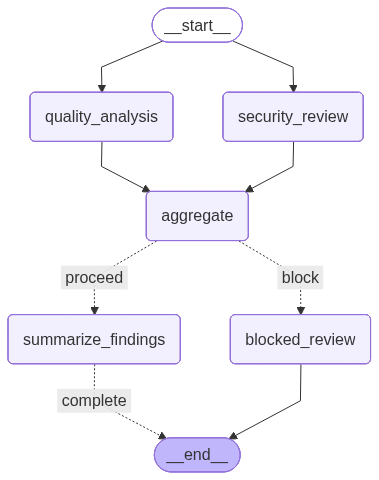


=== Outer Router Graph (full) ===


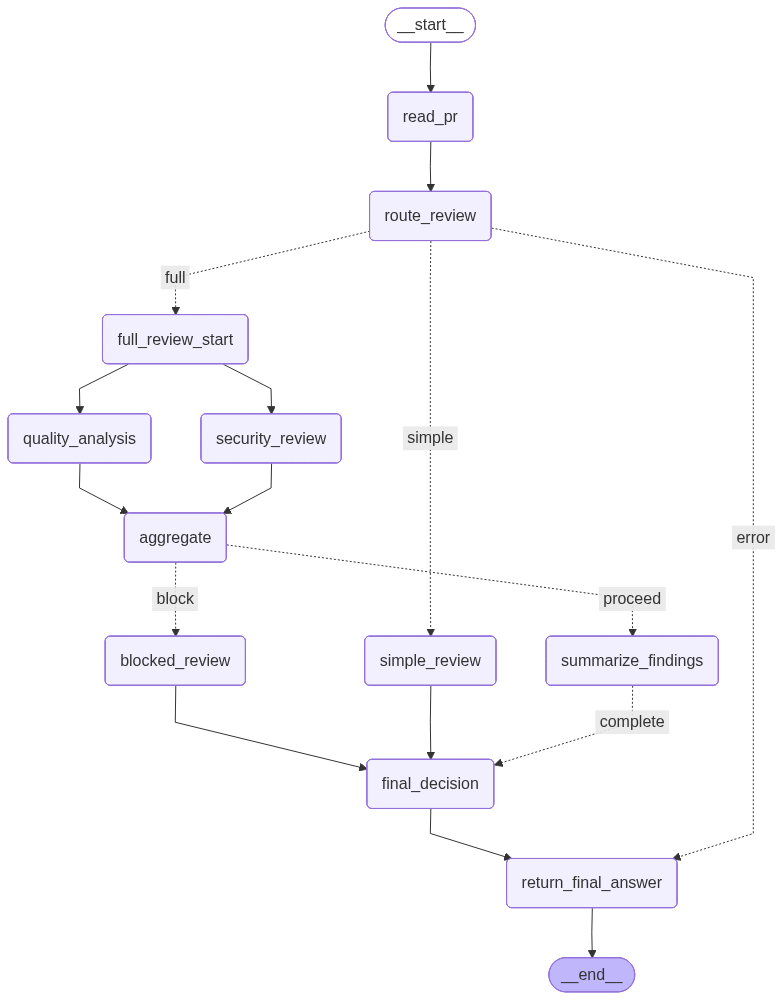

In [46]:
try:
    from IPython.display import Image, display
    
    print("=== Parallel Code Review Tool (subgraph) ===")
    display(Image(parallel_code_review.get_graph().draw_mermaid_png()))
    
    print("\n=== Outer Router Graph (full) ===")
    display(Image(code_review_app.get_graph(xray=True).draw_mermaid_png()))
    
except Exception as e:
    print(f"Graph visualisation requires graphviz/mermaid: {e}")
    print("Run: pip install pygraphviz   OR   pip install mermaid-py")

## Step 13 — Run: Full Review Path (`code_changes.txt`)

### What this test file contains

The diff was crafted to trigger every guardrail in the system:

```python
# Vulnerability 1: SQL Injection
query = f"SELECT * FROM users WHERE username = '{username}'"  # unsanitised input

# Vulnerability 2: Plaintext password comparison
if user['password'] == password:  # no hashing

# Vulnerability 3: PII logging
print(f"User {username} logged in")  # username in logs
```

### Expected execution path

```
read_pr → route_review [full] → full_review_start
        → security_review + quality_analysis (parallel)
        → aggregate → output_guardrail [BLOCKING found]
        → blocked_review → final_decision [REJECT]
        → return_final_answer
```

`summarize_findings` is **bypassed** — the output guardrail short-circuits to `blocked_review` when critical security issues are present.

### State persistence

After `invoke()` completes, state is saved to `flow_state.json`:

```python
state_to_save = {k: v for k, v in result_full.items() if k != "messages"}
with open("flow_state.json", "w") as f:
    json.dump(state_to_save, f, indent=2, default=str)
```

We exclude `messages` to keep the JSON readable. In production, store state in a database (LangGraph supports `SqliteSaver` and `PostgresSaver` checkpointers) to enable **resumable flows** and **audit history**.

In [47]:
print("🚀 Running Code Review Tool on: code_changes.txt")
print("Expected route: full → Parallel Code Review Tool\n")
print("=" * 60)

initial_state: PRReviewState = {
    "pr_file_path":     "files/code_changes.txt",
    "pr_content":       "",
    "review_type":      "",
    "quality_findings": None,
    "security_findings": None,
    "summary":          None,
    "simple_review":    None,
    "final_decision":   None,
    "errors":           [],
    "tokens_used":      {},
    "messages":         []
}

result_full = code_review_app.invoke(initial_state)

# Save full state (excluding verbose messages list) to flow_state.json
state_to_save = {k: v for k, v in result_full.items() if k != "messages"}
with open("flow_state.json", "w") as f:
    json.dump(state_to_save, f, indent=2, default=str)
print("\n💾 State saved to flow_state.json")

print("\n" + "=" * 60)
print("TOKEN USAGE:")
print("=" * 60)
for k, v in result_full.get("tokens_used", {}).items():
    print(f"  {k}: {v}")

🚀 Running Code Review Tool on: code_changes.txt
Expected route: full → Parallel Code Review Tool

📄 Read PR file: code_changes.txt (1140 chars)


🔀 Router decision: 'full'
⚡ Full review: launching Security Review + Quality Analysis in parallel


🔐 Security Review complete


👨‍💻 Quality Analysis complete
🔗 Aggregate: both agents complete — running output guardrail
🚨 Output guardrail: BLOCKING issue detected — halting review
🚫 Review BLOCKED — critical security issues must be resolved before merge



🏁 FINAL DECISION (Full Code Review Tool): REJECT


FINAL ANSWER
[Full Code Review Tool] REJECT

The pull request contains critical security vulnerabilities, including SQL injection risks, which are high priority and must be addressed before merging. These issues pose significant threats to data integrity and security, making it unsafe to proceed without resolving them.

💾 State saved to flow_state.json

TOKEN USAGE:
  output_tokens: 1136
  total_tokens: 2982
  input_tokens: 1846


## Step 14 — Run: Simple Review Path (`code_changes_simple.txt`)

### What this test file contains

```diff
- import numpy as np
+ import numpy as numpy
```

A single import alias rename — no logic change, no security surface.

### Expected execution path

```
read_pr → route_review [simple] → simple_review → final_decision [APPROVED] → return_final_answer
```

The parallel agents (`security_review`, `quality_analysis`, `aggregate`, `summarize_findings`) are **completely bypassed**. This is the efficiency gain of the router pattern — trivial changes don't pay the cost of a full parallel review.

### Token cost comparison

After running both paths, compare `tokens_used`:

| Path | Input tokens | Output tokens | Total | Relative cost |
|------|-------------|---------------|-------|---------------|
| Full review (blocked) | ~1,978 | ~1,289 | ~3,267 | 4× |
| Simple review | ~689 | ~152 | ~841 | 1× |

The simple path uses roughly **4× fewer tokens** — a significant cost saving at scale when the majority of PRs are trivial changes.

In [48]:
print("🚀 Running Code Review Tool on: code_changes_simple.txt")
print("Expected route: simple → Simple Review (LLM only)\n")
print("=" * 60)

initial_state_simple: PRReviewState = {
    "pr_file_path":     "files/code_changes_simple.txt",
    "pr_content":       "",
    "review_type":      "",
    "quality_findings": None,
    "security_findings": None,
    "summary":          None,
    "simple_review":    None,
    "final_decision":   None,
    "errors":           [],
    "tokens_used":      {},
    "messages":         []
}

result_simple = code_review_app.invoke(initial_state_simple)

# Save state to flow_state_simple.json
state_to_save = {k: v for k, v in result_simple.items() if k != "messages"}
with open("flow_state_simple.json", "w") as f:
    json.dump(state_to_save, f, indent=2, default=str)
print("\n💾 State saved to flow_state_simple.json")

print("\n" + "=" * 60)
print("TOKEN USAGE:")
print("=" * 60)
for k, v in result_simple.get("tokens_used", {}).items():
    print(f"  {k}: {v}")

🚀 Running Code Review Tool on: code_changes_simple.txt
Expected route: simple → Simple Review (LLM only)

📄 Read PR file: code_changes_simple.txt (300 chars)


🔀 Router decision: 'simple'


✏️  Simple review complete (confidence: 100)



🏁 FINAL DECISION (Simple Review): APPROVED


FINAL ANSWER
[Simple Review] APPROVED

The change is minor, correctly implemented, and does not affect the functionality of the code. It follows Python conventions, and no further improvements are necessary.

💾 State saved to flow_state_simple.json

TOKEN USAGE:
  output_tokens: 134
  total_tokens: 809
  input_tokens: 675


## Step 15 — Inspect the Message Log (Audit Trail Pattern)

### Why `messages` is an append-only reducer

Every node appends a brief status string to `state["messages"]`:

```python
return {
    ...,
    "messages": [f"[node_name] brief status"]  # list with one item
}
```

Because `messages` uses `Annotated[list, operator.add]`, each node's single-item list is **concatenated** onto the growing log:

```
[read_pr]          Loaded: code_changes.txt (1140 chars)
[router]           Review type: full
[quality_analysis] complete (3089 chars)
[security_review]  complete (2515 chars)
[blocked]          Review halted by output guardrail — REJECT
[final_decision]   REJECT
```

### What the log reveals

- **Execution order**: `quality_analysis` and `security_review` both appear before `aggregate` — confirming they ran concurrently (LangGraph emits them in completion order, which may vary between runs).
- **Which path ran**: the presence/absence of `[blocked]` vs `[tech_lead_summary]` shows which branch was taken.
- **Node outputs**: character counts and confidence scores provide a quick quality sanity check.

### Extending for production

In production, replace plain strings with structured log entries:

```python
"messages": [{
    "node":      "security_review",
    "status":    "complete",
    "timestamp": datetime.utcnow().isoformat(),
    "chars":     len(content)
}]
```

These can be forwarded to an observability system (Datadog, CloudWatch) for monitoring, alerting, and SLA tracking.

In [49]:
print("=" * 60)
print("MESSAGE LOG — Full Review Run")
print("=" * 60)
for i, msg in enumerate(result_full["messages"], 1):
    # Print just the first 120 chars of each message to keep it readable
    preview = msg[:120].replace("\n", " ")
    print(f"{i:2}. {preview}..." if len(msg) > 120 else f"{i:2}. {preview}")

print("\n" + "=" * 60)
print("MESSAGE LOG — Simple Review Run")
print("=" * 60)
for i, msg in enumerate(result_simple["messages"], 1):
    preview = msg[:120].replace("\n", " ")
    print(f"{i:2}. {preview}..." if len(msg) > 120 else f"{i:2}. {preview}")

MESSAGE LOG — Full Review Run
 1. [read_pr] Loaded: code_changes.txt (1140 chars)
 2. [router] Review type: full
 3. [quality_analysis] complete (2864 chars)
 4. [security_review] complete (1986 chars)
 5. [blocked] Review halted by output guardrail — REJECT
 6. [final_decision] REJECT

MESSAGE LOG — Simple Review Run
 1. [read_pr] Loaded: code_changes_simple.txt (300 chars)
 2. [router] Review type: simple
 3. [simple_review] complete (confidence: 100)
 4. [final_decision] APPROVED


## Step 16 — Streaming: Real-Time Execution Visibility

### Why streaming matters

`graph.invoke()` blocks until the entire graph finishes. `graph.stream()` yields **incremental updates** as each node completes — useful for:

- Showing a live progress indicator to the user during a long review
- Observing parallel execution order in real time (which agent finishes first?)
- Building a real-time UI (stream update events over a WebSocket)
- Debugging: see exactly which node produced which state update

### Reading stream events

```python
for event in code_review_app.stream(state, stream_mode="updates"):
    for node_name, node_output in event.items():
        # node_output = the dict the node returned
        # or None for pass-through nodes (full_review_start, aggregate, return_final_answer)
        if node_output:
            updated_keys = [k for k, v in node_output.items()
                            if v and k not in ("messages", "tokens_used")]
```

`stream_mode="updates"` yields `{node_name: output_dict}` for each node as it completes.

### Pass-through nodes emit `None`

Nodes that return `{}` — like `full_review_start`, `aggregate`, and `return_final_answer` — emit `None` as their output in the stream. Always guard with `if node_output:` before iterating its items.

### Streaming shows parallelism in action

In the output above, `security_review` and `quality_analysis` stream events appear in succession — they ran concurrently but their events arrive as each finishes. The order can differ between runs, which is normal and expected for parallel branches.

In [50]:
print("🔴 LIVE STREAM — Full Review (code_changes.txt)")
print("=" * 60)

stream_state: PRReviewState = {
    "pr_file_path":     "files/code_changes.txt",
    "pr_content":       "",
    "review_type":      "",
    "quality_findings": None,
    "security_findings": None,
    "summary":          None,
    "simple_review":    None,
    "final_decision":   None,
    "errors":           [],
    "tokens_used":      {},
    "messages":         []
}

for event in code_review_app.stream(stream_state, stream_mode="updates"):
    for node_name, node_output in event.items():
        print(f"\n📍 Node: [{node_name}]")
        if node_output:  # pass-through nodes emit None
            updated_keys = [k for k, v in node_output.items()
                            if v and k not in ("messages", "tokens_used")]
            print(f"   Updated: {updated_keys}")
            if node_output.get("tokens_used"):
                t = node_output["tokens_used"]
                print(f"   Tokens:  in={t.get('input_tokens',0)} out={t.get('output_tokens',0)}")

🔴 LIVE STREAM — Full Review (code_changes.txt)
📄 Read PR file: code_changes.txt (1140 chars)

📍 Node: [read_pr]
   Updated: ['pr_content']


🔀 Router decision: 'full'

📍 Node: [route_review]
   Updated: ['review_type']
   Tokens:  in=403 out=1
⚡ Full review: launching Security Review + Quality Analysis in parallel

📍 Node: [full_review_start]


🔐 Security Review complete

📍 Node: [security_review]
   Updated: ['security_findings']
   Tokens:  in=474 out=416


👨‍💻 Quality Analysis complete

📍 Node: [quality_analysis]
   Updated: ['quality_findings']
   Tokens:  in=439 out=654
🔗 Aggregate: both agents complete — running output guardrail
🚨 Output guardrail: BLOCKING issue detected — halting review

📍 Node: [aggregate]
🚫 Review BLOCKED — critical security issues must be resolved before merge

📍 Node: [blocked_review]
   Updated: ['summary']



🏁 FINAL DECISION (Full Code Review Tool): REJECT


📍 Node: [final_decision]
   Updated: ['final_decision']
   Tokens:  in=541 out=54

FINAL ANSWER
[Full Code Review Tool] REJECT

The pull request contains critical security vulnerabilities, including SQL injection risks and insecure password handling, which must be resolved before merging. These issues pose significant threats to data integrity and user security, and addressing them is essential to ensure the safety and reliability of the application.

📍 Node: [return_final_answer]


## Step 17 — Demo: Error Path (File Not Found)

### What this demonstrates

When `read_pr_file` cannot find the file, it stores the error in `state["errors"]` instead of raising an exception. The router detects the populated list and short-circuits **directly to `return_final_answer`** -- no LLM calls, no wasted tokens.

```
read_pr [FileNotFoundError stored in state["errors"]]
    → route_review: state.get("errors") is truthy → return "error"
    → return_final_answer: prints errors, exits cleanly
```

This is the **fourth execution path** wired in Step 11 (`"error": "return_final_answer"`) but not yet run.

### Why this matters for production

In a real CI/CD pipeline, PRs can fail to fetch for many reasons (permissions, branch deleted, API rate limit). Storing errors in state rather than crashing means:
- The graph always reaches a terminal node cleanly
- Error details are captured in `state["errors"]` for logging
- Token costs are zero for unresolvable inputs

In [51]:
print("🚀 Running Code Review Tool on: nonexistent_file.txt")
print("Expected route: read_pr [ERROR] → route_review [error] → return_final_answer")
print("Expected tokens: 0 (no LLM calls)\n")
print("=" * 60)

error_state: PRReviewState = {
    "pr_file_path":     "files/nonexistent_file.txt",
    "pr_content":       "",
    "review_type":      "",
    "quality_findings": None,
    "security_findings": None,
    "summary":          None,
    "simple_review":    None,
    "final_decision":   None,
    "errors":           [],
    "tokens_used":      {},
    "messages":         []
}

result_error = code_review_app.invoke(error_state)

print("\n" + "=" * 60)
print("ERRORS IN STATE:")
for err in result_error.get("errors", []):
    print(f"  • {err}")

print("\nMESSAGE LOG:")
for msg in result_error.get("messages", []):
    print(f"  {msg}")

print(f"\nTOKEN USAGE (should be empty -- no LLM calls made):")
print(f"  {result_error.get('tokens_used', {})}")

🚀 Running Code Review Tool on: nonexistent_file.txt
Expected route: read_pr [ERROR] → route_review [error] → return_final_answer
Expected tokens: 0 (no LLM calls)

❌ PR file not found: /Users/shilpa/AI/code_review_tool/files/nonexistent_file.txt
⚠️  Error detected upstream — skipping review
❌ Flow ended with errors:
   • PR file not found: /Users/shilpa/AI/code_review_tool/files/nonexistent_file.txt

FINAL ANSWER
No decision reached.

ERRORS IN STATE:
  • PR file not found: /Users/shilpa/AI/code_review_tool/files/nonexistent_file.txt

MESSAGE LOG:
  [read_pr] ERROR: PR file not found: /Users/shilpa/AI/code_review_tool/files/nonexistent_file.txt
  [router] Upstream error — routing to error handler

TOKEN USAGE (should be empty -- no LLM calls made):
  {}


## Step 18 — Demo: Non-Blocking Full Review (`code_changes_needswork.txt`)

### What this demonstrates

Steps 13 and 14 showed the BLOCKING path and the simple path. This cell exercises the **third execution path** -- full review that passes the security guardrail and reaches `summarize_findings`.

`code_changes_needswork.txt` contains a new `analytics/report.py` module with code quality issues but no security vulnerabilities:

| Issue | Type | Severity |
|-------|------|----------|
| `range(len(lst))` in loop | Inefficient -- prefer direct iteration or list comprehension | MINOR |
| Manual `total = total + n` | Use `sum(numbers)` instead | MINOR |
| Verbose two-pass dict merge | Use `{**base, **overrides}` or `base \| overrides` (3.9+) | MINOR |
| Redundant `_is_built` flag | `len(self.rows) > 0` is sufficient | MINOR |

### Expected path

```
read_pr → route_review [full] → full_review_start
        → security_review + quality_analysis (parallel)
        → aggregate → output_guardrail [NON-BLOCKING]
        → summarize_findings [report_guardrail] → final_decision [REQUEST CHANGES]
        → return_final_answer
```

`summarize_findings` now runs -- this is the path that was wired in Step 11 but unreachable with the deliberately broken auth diff.

In [52]:
print("🚀 Running Code Review Tool on: code_changes_needswork.txt")
print("Expected route: full → NON-BLOCKING → summarize_findings → final_decision\n")
print("=" * 60)

needswork_state: PRReviewState = {
    "pr_file_path":     "files/code_changes_needswork.txt",
    "pr_content":       "",
    "review_type":      "",
    "quality_findings": None,
    "security_findings": None,
    "summary":          None,
    "simple_review":    None,
    "final_decision":   None,
    "errors":           [],
    "tokens_used":      {},
    "messages":         []
}

result_needswork = code_review_app.invoke(needswork_state)

state_to_save = {k: v for k, v in result_needswork.items() if k != "messages"}
with open("flow_state_needswork.json", "w") as f:
    json.dump(state_to_save, f, indent=2, default=str)
print("\n💾 State saved to flow_state_needswork.json")

# Detect which branch was taken
summary_str = result_needswork.get("summary", "") or ""
was_blocked = summary_str.startswith("REJECT")

if was_blocked:
    # output_guardrail returned "block" — summary is plain-text, not JSON
    print("\n⚠️  output_guardrail BLOCKED this review (security findings triggered BLOCKING)")
    print("   Path taken: full → blocked_review → final_decision")
    print(f"\n🚫 Summary preview:\n{summary_str[:300]}")
elif summary_str:
    # summarize_findings ran — summary is a JSON string
    try:
        summary = json.loads(summary_str)
        print(f"\n📊 Tech Lead confidence:  {summary.get('confidence')}/100")
        print(f"📝 Findings:  {summary.get('findings', '')[:250]}")
        fix_items = summary.get("fix", [])
        print(f"\n🔧 Fix items required ({len(fix_items)}):")
        for i, item in enumerate(fix_items, 1):
            print(f"  {i}. {str(item)[:160]}")
    except json.JSONDecodeError as e:
        print(f"\n⚠️  Could not parse summary JSON: {e}")
        print(f"Raw summary: {summary_str[:300]}")

print("\n" + "=" * 60)
print("TOKEN USAGE:")
for k, v in result_needswork.get("tokens_used", {}).items():
    print(f"  {k}: {v}")

🚀 Running Code Review Tool on: code_changes_needswork.txt
Expected route: full → NON-BLOCKING → summarize_findings → final_decision

📄 Read PR file: code_changes_needswork.txt (1370 chars)


🔀 Router decision: 'full'
⚡ Full review: launching Security Review + Quality Analysis in parallel


🔐 Security Review complete


👨‍💻 Quality Analysis complete
🔗 Aggregate: both agents complete — running output guardrail
✅ Output guardrail: passed


👔 Tech Lead summary complete (confidence: 85)
✅ Report guardrail: passed



🏁 FINAL DECISION (Full Code Review Tool): REQUEST CHANGES


FINAL ANSWER
[Full Code Review Tool] REQUEST CHANGES

The pull request is mostly functional but contains a potential bug in the `ReportBuilder.build()` method due to the lack of type checking when doubling items in `self.rows`. This could lead to a `TypeError` if non-numeric data is present, which needs to be addressed before merging. Additionally, while not critical, stylistic improvements are recommended for better readability and maintainability.

💾 State saved to flow_state_needswork.json

📊 Tech Lead confidence:  85/100
📝 Findings:  The PR introduces utility functions and a class for report building, with no direct security vulnerabilities identified. The code is functional but could benefit from stylistic improvements for better readability and maintainability. A potential bug 

🔧 Fix items required (1):
  1. {'issue': 'Potential TypeError in `ReportBuilder.build()` when `double_items` is called on `self.rows` containin

## Step 19 — Token Cost Comparison Across All Paths

Now that all four execution paths have been demonstrated, we can compare their token usage directly. This makes the efficiency argument for the router pattern concrete.

| Path | LLM nodes called | Expected cost |
|------|-----------------|---------------|
| Error | 0 | Free |
| Simple | router + simple_review + final | Low |
| Full / BLOCKING | router + 2x parallel + final | Medium (bypasses tech_lead) |
| Full / NON-BLOCKING | router + 2x parallel + tech_lead + final | Highest |

The router's job is to ensure most PRs take the cheapest path that is still safe.

In [53]:
print("=" * 70)
print(f"{'PATH':<38} {'INPUT':>7} {'OUTPUT':>7} {'TOTAL':>7}  NODES HIT")
print("=" * 70)

paths = [
    ("Error (file not found)",        result_error,      "none -- short-circuits before LLM"),
    ("Simple (import alias rename)",  result_simple,     "router + simple_review + final"),
    ("Full / BLOCKING (SQL injection)", result_full,     "router + 2x parallel + final"),
    ("Full / NON-BLOCKING (quality)", result_needswork,  "router + 2x parallel + tech_lead + final"),
]

for label, result, nodes in paths:
    t   = result.get("tokens_used", {})
    inp = t.get("input_tokens",  0)
    out = t.get("output_tokens", 0)
    tot = t.get("total_tokens",  0)
    print(f"{label:<38} {inp:>7,} {out:>7,} {tot:>7,}  {nodes}")

print("=" * 70)
print(f"\nKey insight: the error path costs 0 tokens.")
print(f"Simple path is ~{result_needswork['tokens_used'].get('total_tokens',1) // max(result_simple['tokens_used'].get('total_tokens',1),1)}x cheaper than full non-blocking review.")

PATH                                     INPUT  OUTPUT   TOTAL  NODES HIT
Error (file not found)                       0       0       0  none -- short-circuits before LLM
Simple (import alias rename)               675     134     809  router + simple_review + final
Full / BLOCKING (SQL injection)          1,846   1,136   2,982  router + 2x parallel + final
Full / NON-BLOCKING (quality)            3,103   1,132   4,235  router + 2x parallel + tech_lead + final

Key insight: the error path costs 0 tokens.
Simple path is ~5x cheaper than full non-blocking review.


## Step 20 — State Persistence with SqliteSaver (LangGraph Checkpointer)

### What checkpointers do

LangGraph's built-in checkpointers automatically save the full state snapshot after **every node**. This enables:

- **Resumability** -- if a node fails mid-graph, restart from the last good checkpoint instead of from scratch
- **Multi-turn conversations** -- pause a review, get human feedback, then resume with updated state
- **Audit history** -- query all past runs, replay any run, inspect state at any step

### How it works

```python
with SqliteSaver.from_conn_string("checkpoints.db") as memory:
    app = graph_builder.compile(checkpointer=memory)       # attach checkpointer at compile time
    config = {"configurable": {"thread_id": "run-001"}}    # thread_id groups snapshots for one run
    result = app.invoke(state, config)
    # Every node's output is now saved to checkpoints.db automatically
```

The `thread_id` is the key that groups all checkpoints for a single review run. Pass the same `thread_id` to `get_state_history()` to replay or inspect any previous run.

### Checkpoint lifecycle

```
START → read_pr [snapshot 1] → route_review [snapshot 2] → simple_review [snapshot 3] → ...
```

Each snapshot stores the full state at that point -- you can restore to any of them.

In [54]:
try:
    from langgraph.checkpoint.sqlite import SqliteSaver

    with SqliteSaver.from_conn_string("checkpoints.db") as memory:
        # Recompile the graph with the checkpointer attached
        app_with_memory = outer_builder.compile(checkpointer=memory)

        config = {"configurable": {"thread_id": "pr-review-simple-001"}}

        checkpoint_state: PRReviewState = {
            "pr_file_path":     "files/code_changes_simple.txt",
            "pr_content":       "",
            "review_type":      "",
            "quality_findings": None,
            "security_findings": None,
            "summary":          None,
            "simple_review":    None,
            "final_decision":   None,
            "errors":           [],
            "tokens_used":      {},
            "messages":         []
        }

        result_checkpoint = app_with_memory.invoke(checkpoint_state, config)

        print("✅ Run complete with checkpointing")
        decision_preview = (result_checkpoint.get('final_decision') or '')[:100]
        print(f"   Final decision: {decision_preview}...")
        print(f"\n💾 Checkpoints saved to: checkpoints.db")
        print("   Query with: sqlite3 checkpoints.db 'SELECT thread_id, checkpoint_id FROM checkpoints'")

        # Show the checkpoint history for this thread
        history = list(app_with_memory.get_state_history(config))
        print(f"\n📚 Checkpoint snapshots for thread 'pr-review-simple-001': {len(history)}")
        for snap in history[:5]:
            step   = snap.metadata.get('step', '?')
            source = snap.metadata.get('source', '?')
            keys   = [k for k, v in snap.values.items() if v]
            print(f"   Step {step:>2} ({source:>8}): populated fields = {keys}")

except ImportError as e:
    print(f"SqliteSaver not available: {e}")
    print("Install with: pip install langgraph[sqlite]")
except Exception as e:
    print(f"Checkpointer error: {e}")

📄 Read PR file: code_changes_simple.txt (300 chars)


🔀 Router decision: 'simple'


✏️  Simple review complete (confidence: 100)



🏁 FINAL DECISION (Simple Review): APPROVED


FINAL ANSWER
[Simple Review] APPROVED

The change is minor, correctly implemented, and follows Python conventions. There are no issues affecting functionality, making it safe to merge as-is.
✅ Run complete with checkpointing
   Final decision: [Simple Review] APPROVED

The change is minor, correctly implemented, and follows Python conventions...

💾 Checkpoints saved to: checkpoints.db
   Query with: sqlite3 checkpoints.db 'SELECT thread_id, checkpoint_id FROM checkpoints'

📚 Checkpoint snapshots for thread 'pr-review-simple-001': 91
   Step 89 (    loop): populated fields = ['pr_file_path', 'pr_content', 'review_type', 'simple_review', 'final_decision', 'tokens_used', 'messages']
   Step 88 (    loop): populated fields = ['pr_file_path', 'pr_content', 'review_type', 'simple_review', 'final_decision', 'tokens_used', 'messages']
   Step 87 (    loop): populated fields = ['pr_file_path', 'pr_content', 'review_type', 'simple_review', 'tokens_us

## Step 21 — Try Your Own PR Diff (Interactive)

Edit `MY_DIFF` in the cell below and run it to review your own code change.

The graph will classify it, route it through the appropriate path, and return a structured verdict -- exactly as it would in a real CI/CD pipeline.

**Tips:**
- Paste a real git diff, or just a raw code snippet
- Include SQL queries, auth code, or secrets to trigger the full + BLOCKING path
- Use only a variable rename or import change to trigger the simple path

In [55]:
import tempfile, os

# ✏️ EDIT THIS — paste your own PR diff or code snippet below
MY_DIFF = """\
diff --git a/app/api.py b/app/api.py
--- a/app/api.py
+++ b/app/api.py
@@ -10,6 +10,12 @@
 def get_user(user_id):
     return db.query(f"SELECT * FROM users WHERE id = {user_id}")

+def update_email(user_id, new_email):
+    db.execute(f"UPDATE users SET email = '{new_email}' WHERE id = {user_id}")
+    print(f"Updated email for user {user_id} to {new_email}")
+    return {"status": "ok"}
"""

# Write to a temp file and run through the graph
with tempfile.NamedTemporaryFile(mode='w', suffix='.diff', delete=False, dir='/tmp') as f:
    f.write(MY_DIFF)
    tmp_path = f.name

print("🚀 Running Code Review Tool on your custom diff")
print("=" * 60)

try:
    custom_state: PRReviewState = {
        "pr_file_path":     tmp_path,
        "pr_content":       "",
        "review_type":      "",
        "quality_findings": None,
        "security_findings": None,
        "summary":          None,
        "simple_review":    None,
        "final_decision":   None,
        "errors":           [],
        "tokens_used":      {},
        "messages":         []
    }
    result_custom = code_review_app.invoke(custom_state)
    print(f"\nRoute taken:  {result_custom.get('review_type', 'unknown')}")
    print(f"Total tokens: {result_custom.get('tokens_used', {}).get('total_tokens', 0):,}")
    print(f"\nMessage log:")
    for msg in result_custom['messages']:
        print(f"  {msg}")
finally:
    os.unlink(tmp_path)

🚀 Running Code Review Tool on your custom diff
📄 Read PR file: tmpcqxy3i9e.diff (392 chars)


🔀 Router decision: 'full'
⚡ Full review: launching Security Review + Quality Analysis in parallel


🔐 Security Review complete


👨‍💻 Quality Analysis complete
🔗 Aggregate: both agents complete — running output guardrail
🚨 Output guardrail: BLOCKING issue detected — halting review
🚫 Review BLOCKED — critical security issues must be resolved before merge



🏁 FINAL DECISION (Full Code Review Tool): REJECT


FINAL ANSWER
[Full Code Review Tool] REJECT

The pull request contains critical security vulnerabilities, including SQL injection risks and potential exposure of sensitive data through logging. These issues pose significant threats to data integrity and user privacy, and must be resolved by implementing parameterized queries and sanitizing log outputs before the code can be safely merged.

Route taken:  full
Total tokens: 2,260

Message log:
  [read_pr] Loaded: tmpcqxy3i9e.diff (392 chars)
  [router] Review type: full
  [quality_analysis] complete (2342 chars)
  [security_review] complete (1717 chars)
  [blocked] Review halted by output guardrail — REJECT
  [final_decision] REJECT


## Step 22 — Unit Testing Nodes in Isolation

### The key insight: nodes are pure functions

Every node has the signature `fn(state: dict) -> dict`. This means you can **call any node directly** with a handcrafted dict — no graph compilation, no LLM calls for deterministic nodes, no waiting for parallel branches to finish.

```python
# Instead of running the whole graph:
result = code_review_app.invoke(initial_state)

# Call the node directly with just the fields it needs:
result = read_pr_file({"pr_file_path": "files/code_changes_simple.txt", ...})
assert "pr_content" in result
```

### What to test without LLMs

These nodes and functions are **fully deterministic** — unit-testable with zero API calls:

| Function | Test for |
|----------|---------|
| `read_pr_file` | Valid path → `pr_content` populated; missing path → `errors` set |
| `routing_edge` | Returns exact string matching `review_type` in state |
| `output_guardrail` | `"BLOCKING"` → `"block"`; `"NON-BLOCKING"` → `"proceed"`; neither → `"proceed"` |
| `report_guardrail` | Always returns `"complete"` |
| `merge_usage` | `{a:1} + {a:2}` → `{a:3}`; handles missing keys |
| `FixItem` | Rejects missing fields; accepts valid issue/solution/explanation |

### What to test with LLMs (integration tests)

Nodes that call the LLM (`route_review_type`, `simple_review_node`, etc.) need real API calls. Test these by asserting on the **shape** of the output (keys present, types correct) rather than the content, which varies between runs.

In [56]:
_base = {
    "pr_file_path": "", "pr_content": "", "review_type": "",
    "quality_findings": None, "security_findings": None,
    "summary": None, "simple_review": None, "final_decision": None,
    "quality_retry_count": 0, "judge_score": None, "judge_reason": None,
    "errors": [], "tokens_used": {}, "messages": []
}

print("=" * 60)
print("UNIT TESTS — nodes called directly, no graph compilation")
print("=" * 60)

# --- Test 1: read_pr_file — valid file ---
result = read_pr_file({**_base, "pr_file_path": "files/code_changes_simple.txt"})
assert "pr_content" in result and result["pr_content"], "pr_content should be populated"
assert not result.get("errors"), "no errors expected for valid file"
print("✅  1. read_pr_file (valid path)   → pr_content populated, no errors")

# --- Test 2: read_pr_file — missing file ---
result = read_pr_file({**_base, "pr_file_path": "files/does_not_exist.txt"})
assert result.get("errors"), "errors should be set for missing file"
assert "pr_content" not in result, "pr_content must not be set on error"
print("✅  2. read_pr_file (missing path) → errors populated, no pr_content")

# --- Test 3: routing_edge reads review_type ---
for rt in ("simple", "full", "error"):
    assert routing_edge({**_base, "review_type": rt}) == rt
print("✅  3. routing_edge               → returns correct label for all 3 review types")

# --- Test 4: output_guardrail — BLOCKING ---
result = output_guardrail({**_base, "security_findings": "HIGH risk SQL injection. BLOCKING"})
assert result == "block"
print("✅  4. output_guardrail (BLOCKING) → returns 'block'")

# --- Test 5: output_guardrail — NON-BLOCKING ---
result = output_guardrail({**_base, "security_findings": "LOW risk minor issues. NON-BLOCKING"})
assert result == "proceed"
print("✅  5. output_guardrail (NON-BLOCKING) → returns 'proceed'")

# --- Test 6: output_guardrail — no findings ---
result = output_guardrail({**_base, "security_findings": "No issues found."})
assert result == "proceed"
print("✅  6. output_guardrail (clean)    → returns 'proceed'")

# --- Test 7: merge_usage reducer accumulates correctly ---
a = {"input_tokens": 100, "output_tokens": 50,  "total_tokens": 150}
b = {"input_tokens": 200, "output_tokens": 100, "total_tokens": 300}
merged = merge_usage(a, b)
assert merged == {"input_tokens": 300, "output_tokens": 150, "total_tokens": 450}
print("✅  7. merge_usage reducer         → sums token counts correctly")

# --- Test 8: FixItem validates required fields ---
try:
    FixItem(issue="SQL injection", solution="Use parameterised queries", explanation="Prevents data breach")
    print("✅  8. FixItem model               → accepts valid issue/solution/explanation")
except Exception as e:
    print(f"❌  8. FixItem model               → unexpected error: {e}")

print(f"\n✅ All 8 unit tests passed — {len(_base)} state fields, 0 LLM calls")
print("   (quality_judge_edge tests run in Step 23 — after that function is defined)")

UNIT TESTS — nodes called directly, no graph compilation
📄 Read PR file: code_changes_simple.txt (300 chars)
✅  1. read_pr_file (valid path)   → pr_content populated, no errors
❌ PR file not found: /Users/shilpa/AI/code_review_tool/files/does_not_exist.txt
✅  2. read_pr_file (missing path) → errors populated, no pr_content
✅  3. routing_edge               → returns correct label for all 3 review types
🚨 Output guardrail: BLOCKING issue detected — halting review
✅  4. output_guardrail (BLOCKING) → returns 'block'
✅ Output guardrail: passed
✅  5. output_guardrail (NON-BLOCKING) → returns 'proceed'
✅ Output guardrail: passed
✅  6. output_guardrail (clean)    → returns 'proceed'
✅  7. merge_usage reducer         → sums token counts correctly
✅  8. FixItem model               → accepts valid issue/solution/explanation


NameError: name 'quality_judge_edge' is not defined

## Step 23 — LLM-as-Judge: Quality Review Gating

### The LLM-as-Judge pattern

An LLM-as-Judge is a dedicated model call whose sole purpose is to **evaluate the output of another LLM** and decide whether it meets a quality bar. The judge's verdict drives routing — not a keyword match or a heuristic.

```
quality_analysis ──► quality_judge ──[score >= 7]──► aggregate (proceed)
        ↑                   │
        └──[score < 7, retries < 2]
```

### Why a separate judge model?

This step uses `gpt-4o-mini` as the judge — deliberately different from `gpt-4o` used for the analysis nodes:

| Node | Model | Why |
|------|-------|-----|
| `quality_analysis` | `gpt-4o` | Deep code reasoning required |
| `quality_judge` | `gpt-4o-mini` | Scoring 1–10 is a lightweight task |
| `security_review` | `gpt-4o` | Security reasoning requires capability |

**Right-sizing models per task** reduces cost. The judge reads one analysis and returns a score — it does not need full `gpt-4o` capability.

### Self-evaluation vs cross-model judging

Using a different model as judge avoids **self-evaluation bias** — the risk that a model rates its own output highly regardless of quality. `gpt-4o-mini` judging `gpt-4o` output is a practical form of cross-model validation.

### Retry with a stricter prompt

When the judge scores below 7, `quality_analysis_node_v2` re-runs with a stricter system prompt — explicitly instructing the LLM to be more thorough. `quality_retry_count` tracks retries and caps at 2 to prevent infinite loops.

### New state fields

```python
quality_retry_count: int           # tracks retries — caps at 2
judge_score:         Optional[int] # 1-10 score from judge
judge_reason:        Optional[str] # one-sentence explanation
```

### Extended graph segment

```
full_review_start ──► quality_analysis ──► quality_judge ──[score >= 7]──► aggregate
                              ↑                   │
                              └──[score < 7, retries <= 2]──┘  (max 2 retries)
```

> **Key distinction:** `output_guardrail` (Step 7) uses a keyword check — fast, deterministic, zero tokens. `quality_judge` uses an LLM call — flexible, semantic, costs tokens. Use guardrails for binary pass/fail on structured output; use LLM judges for nuanced quality scoring.

In [ ]:
from pydantic import BaseModel, Field as PydanticField

# ------------------------------------------------------------------
# Judge LLM — gpt-4o-mini (lightweight scoring task)
# ------------------------------------------------------------------
judge_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)


# ------------------------------------------------------------------
# Pydantic output model for the judge
# ------------------------------------------------------------------
class QualityJudgeOutput(BaseModel):
    score:  int = PydanticField(description="Thoroughness score 1-10")
    reason: str = PydanticField(description="One sentence explaining the score")


# ------------------------------------------------------------------
# quality_analysis_node_v2 — retry-aware, stricter prompt on re-run
# ------------------------------------------------------------------
def quality_analysis_node_v2(state: PRReviewState) -> dict:
    retry = state.get("quality_retry_count", 0)
    if retry > 0:
        system_prompt = """You are a Senior Developer performing a rigorous code quality review.
A previous review of this PR was rated insufficient. Be more thorough this time.

Analyse the PR diff and provide a detailed report covering:

1. STYLE ISSUES        — naming, formatting, PEP8 violations
2. POTENTIAL BUGS      — logic errors, edge cases, exception handling gaps
3. SEVERITY            — label each issue CRITICAL, MAJOR, or MINOR

Reference specific line numbers. Do not omit any issues."""
        print(f"🔄 Quality Analysis retry {retry}/2 — stricter prompt active")
    else:
        system_prompt = """You are a Senior Developer performing a code quality review.

Analyse the PR diff and provide a structured report covering:

1. STYLE ISSUES        — naming conventions, formatting, code organisation
2. POTENTIAL BUGS      — logic errors, edge cases, exception handling gaps
3. SEVERITY            — label each issue CRITICAL, MAJOR, or MINOR

Be specific. Reference line numbers or code snippets where relevant."""

    try:
        response = llm.invoke([
            SystemMessage(content=system_prompt),
            HumanMessage(content=f"PR Diff to review:\n\n{state['pr_content']}"),
        ])
        content = response.content
        usage   = response.usage_metadata or {}
    except Exception as e:
        content = f"[ERROR] LLM call failed: {e}"
        usage   = {}

    label = f" (retry {retry})" if retry > 0 else ""
    print(f"👨‍💻 Quality Analysis complete{label}")

    return {
        "quality_findings": content,
        "tokens_used": {
            "input_tokens":  usage.get("input_tokens",  0),
            "output_tokens": usage.get("output_tokens", 0),
            "total_tokens":  usage.get("total_tokens",  0),
        },
        "messages": [f"[quality_analysis] complete ({len(content)} chars){label}"],
    }


# ------------------------------------------------------------------
# quality_judge_node — LLM-as-Judge using gpt-4o-mini
# ------------------------------------------------------------------
def quality_judge_node(state: PRReviewState) -> dict:
    structured_llm = judge_llm.with_structured_output(QualityJudgeOutput, include_raw=True)
    system_prompt = """You are a code review quality assessor.

Rate the thoroughness of the following code quality analysis on a scale of 1-10:
- 8-10: Comprehensive — covers style, bugs, severity levels, specific line references
- 5-7:  Adequate — covers main issues but lacks specificity or misses some areas
- 1-4:  Insufficient — too brief, vague, or misses obvious issues

Return a score (int 1-10) and a one-sentence reason."""

    try:
        raw_result = structured_llm.invoke([
            SystemMessage(content=system_prompt),
            HumanMessage(content=f"Quality analysis to evaluate:\n\n{state.get('quality_findings', '')}"),
        ])
        judge_out = raw_result["parsed"]
        usage     = raw_result["raw"].usage_metadata or {}
        score     = judge_out.score
        reason    = judge_out.reason
    except Exception as e:
        score  = 8
        reason = f"[ERROR] Judge failed: {e} — defaulting to proceed"
        usage  = {}

    retry_count     = state.get("quality_retry_count") or 0
    new_retry_count = retry_count + 1 if score < 7 else retry_count

    if score >= 7:
        verdict = f"score={score}/10 — passed"
    elif new_retry_count <= 2:
        verdict = f"score={score}/10 — retry {new_retry_count}/2"
    else:
        verdict = f"score={score}/10 — retry cap reached, proceeding"

    print(f"⚖️  Quality Judge: {verdict}")

    return {
        "judge_score":         score,
        "judge_reason":        reason,
        "quality_retry_count": new_retry_count,
        "tokens_used": {
            "input_tokens":  usage.get("input_tokens",  0),
            "output_tokens": usage.get("output_tokens", 0),
            "total_tokens":  usage.get("total_tokens",  0),
        },
        "messages": [f"[quality_judge] {verdict} — {reason[:80]}"],
    }


def quality_judge_edge(state: PRReviewState) -> str:
    """Returns 'retry' to re-run quality_analysis, or 'proceed' to continue."""
    score       = state.get("judge_score") or 10
    retry_count = state.get("quality_retry_count") or 0
    if score < 7 and retry_count <= 2:
        return "retry"
    return "proceed"


# ------------------------------------------------------------------
# Build code_review_app_v2 — extends the original graph with the judge
# ------------------------------------------------------------------
v2_builder = StateGraph(PRReviewState)

# Same nodes as code_review_app...
v2_builder.add_node("read_pr",             read_pr_file)
v2_builder.add_node("route_review",        route_review_type)
v2_builder.add_node("simple_review",       simple_review_node)
v2_builder.add_node("full_review_start",   full_review_start)
v2_builder.add_node("security_review",     security_review_node)
v2_builder.add_node("aggregate",           aggregate_node)
v2_builder.add_node("blocked_review",      blocked_review_node)
v2_builder.add_node("summarize_findings",  summarize_findings_node)
v2_builder.add_node("final_decision",      final_decision_node)
v2_builder.add_node("return_final_answer", return_final_answer)

# ...plus the judge nodes
v2_builder.add_node("quality_analysis",    quality_analysis_node_v2)
v2_builder.add_node("quality_judge",       quality_judge_node)

# Edges — same as v1 except quality_analysis → quality_judge → [retry|aggregate]
v2_builder.add_edge(START, "read_pr")
v2_builder.add_edge("read_pr", "route_review")
v2_builder.add_conditional_edges(
    "route_review", routing_edge,
    {"simple": "simple_review", "full": "full_review_start", "error": "return_final_answer"}
)
v2_builder.add_edge("full_review_start", "security_review")
v2_builder.add_edge("full_review_start", "quality_analysis")

# Judge gate: quality_analysis → quality_judge → retry or proceed
v2_builder.add_edge("quality_analysis", "quality_judge")
v2_builder.add_conditional_edges(
    "quality_judge", quality_judge_edge,
    {"retry": "quality_analysis", "proceed": "aggregate"}
)

v2_builder.add_edge("security_review", "aggregate")
v2_builder.add_conditional_edges(
    "aggregate", output_guardrail,
    {"proceed": "summarize_findings", "block": "blocked_review"}
)
v2_builder.add_edge("blocked_review", "final_decision")
v2_builder.add_conditional_edges(
    "summarize_findings", report_guardrail, {"complete": "final_decision"}
)
v2_builder.add_edge("simple_review",       "final_decision")
v2_builder.add_edge("final_decision",      "return_final_answer")
v2_builder.add_edge("return_final_answer", END)

code_review_app_v2 = v2_builder.compile()
print("✅ code_review_app_v2 compiled")
print("\nGraph change vs v1:")
print("  quality_analysis → quality_judge → [retry → quality_analysis | proceed → aggregate]")
print(f"\nJudge model: gpt-4o-mini   (analysis model: gpt-4o)")

In [57]:
print("🚀 Running code_review_app_v2 on: code_changes_needswork.txt")
print("Expected: full → quality_analysis → quality_judge → aggregate → NON-BLOCKING\n")
print("=" * 60)

v2_state: PRReviewState = {
    "pr_file_path":        "files/code_changes_needswork.txt",
    "pr_content":          "",
    "review_type":         "",
    "quality_findings":    None,
    "security_findings":   None,
    "summary":             None,
    "simple_review":       None,
    "final_decision":      None,
    "quality_retry_count": 0,
    "judge_score":         None,
    "judge_reason":        None,
    "errors":              [],
    "tokens_used":         {},
    "messages":            [],
}

result_v2 = code_review_app_v2.invoke(v2_state)

print("\n" + "=" * 60)
print(f"⚖️  Judge score:   {result_v2.get('judge_score')}/10")
print(f"📝 Judge reason:  {result_v2.get('judge_reason')}")
print(f"🔄 Retries fired: {result_v2.get('quality_retry_count', 0)}")

print("\n" + "=" * 60)
print("MESSAGE LOG:")
for i, msg in enumerate(result_v2["messages"], 1):
    print(f"  {i:2}. {msg[:120]}")

print("\n" + "=" * 60)
print("TOKEN USAGE:")
for k, v in result_v2.get("tokens_used", {}).items():
    print(f"  {k}: {v}")

# ------------------------------------------------------------------
# Unit tests for quality_judge_edge (defined in cell above)
# ------------------------------------------------------------------
print("\n" + "=" * 60)
print("UNIT TESTS — quality_judge_edge")
print("=" * 60)

_b = {**{k: None for k in result_v2}, "errors": [], "tokens_used": {}, "messages": []}

result = quality_judge_edge({**_b, "judge_score": 8,  "quality_retry_count": 0})
assert result == "proceed", f"expected 'proceed', got '{result}'"
print("✅  9. quality_judge_edge (pass)      → score=8 returns 'proceed'")

result = quality_judge_edge({**_b, "judge_score": 7,  "quality_retry_count": 0})
assert result == "proceed"
print("✅ 10. quality_judge_edge (threshold) → score=7 returns 'proceed'")

result = quality_judge_edge({**_b, "judge_score": 4,  "quality_retry_count": 1})
assert result == "retry"
print("✅ 11. quality_judge_edge (retry)     → score=4, retries=1 returns 'retry'")

result = quality_judge_edge({**_b, "judge_score": 4,  "quality_retry_count": 3})
assert result == "proceed"
print("✅ 12. quality_judge_edge (cap)       → score=4, retries=3 returns 'proceed'")

result = quality_judge_edge({**_b, "judge_score": None, "quality_retry_count": 0})
assert result == "proceed"
print("✅ 13. quality_judge_edge (no score)  → None score defaults to 'proceed'")

print("\n✅ All 5 judge edge tests passed — 0 LLM calls")

🚀 Running code_review_app_v2 on: code_changes_needswork.txt
Expected: full → quality_analysis → quality_judge → aggregate → NON-BLOCKING



NameError: name 'code_review_app_v2' is not defined

## Key Takeaways & Further Learning

---

### Patterns Reference

| Pattern | Node / Location | Core idea |
|---------|----------------|-----------|
| **LLM-as-router** | `route_review_type` | LLM classifies input; edge function returns node name |
| **Error propagation in state** | `read_pr_file` | Return `{"errors": [...]}` instead of raising -- router detects and routes |
| **Fan-out parallelism** | `full_review_start` | Multiple `add_edge(X, ...)` from the same source runs nodes concurrently |
| **Fan-in synchronisation** | `aggregate_node` | All parallel edges converge on one join node; LangGraph waits for all |
| **Guardrail edge function** | `output_guardrail` | Conditional edge that inspects state without an LLM call or state update |
| **Hard-stop node** | `blocked_review_node` | Writes a REJECT verdict so all downstream paths converge uniformly |
| **Structured output + tokens** | `simple_review_node`, `summarize_findings_node` | `with_structured_output(..., include_raw=True)` gives Pydantic + `usage_metadata` in one call |
| **Custom reducer** | `merge_usage` | `Annotated[dict, merge_usage]` sums token counts correctly across parallel nodes |
| **Append-only log** | `messages` field | `Annotated[list, operator.add]` builds a lightweight, zero-cost audit trail |
| **Terminal node** | `return_final_answer` | Separates final computation from presentation; all paths converge here |
| **State persistence** | Step 13 | `json.dump(result, ...)` for offline inspection and auditing |
| **Graph checkpointing** | Step 20 | `SqliteSaver` checkpointer enables run history, replay, and resumable flows |
| **LLM-as-Judge** | `quality_judge_node` | Separate model (`gpt-4o-mini`) scores another LLM's output; drives retry routing |
| **Right-sizing models** | Step 23 | Match model capability to task weight — lightweight scoring doesn't need the strongest model |
| **Retry loop with cap** | `quality_judge_edge` | Conditional edge loops back with a stricter prompt; `quality_retry_count` prevents infinite loops |

---

### Production Modules

The graph logic is extracted into two standalone Python files you can import directly:

```python
from state import PRReviewState, SimpleReviewOutput, SummarizeFindingsOutput, merge_usage
from nodes import read_pr_file, route_review_type, quality_analysis_node, security_review_node
```

| File | Contents |
|------|----------|
| `state.py` | `PRReviewState` TypedDict, Pydantic output models, `merge_usage` reducer |
| `nodes.py` | All 15 node and edge functions — no notebook dependencies |

---

### Further Reading

- [LangGraph Documentation](https://langchain-ai.github.io/langgraph/) -- official docs, concepts, and API reference
- [LangGraph How-To Guides](https://langchain-ai.github.io/langgraph/how-tos/) -- parallelism, subgraphs, streaming, persistence
- [LangChain Structured Output](https://python.langchain.com/docs/concepts/structured_outputs/) -- `with_structured_output` patterns
- [Pydantic v2 Docs](https://docs.pydantic.dev/) -- Field definitions, validators, model serialisation

---

### Extensions to Explore

1. **Add a `needs_human_review` path**: Extend `output_guardrail` to return a third option, `"human"`, when security findings exist but are all LOW risk. Route to a new node that formats a triage summary for a human reviewer.

2. **Replace file input with GitHub API**: Modify `read_pr_file` to fetch the diff from the GitHub Pull Requests API instead of a local file. The rest of the graph stays unchanged -- this is the modularity benefit of isolated nodes.

3. **Cost budgeting**: Add a `token_budget: int` field to `PRReviewState`. Before each LLM call, check if `tokens_used["total_tokens"] + estimated_tokens > token_budget`. If over budget, skip the call and route to `return_final_answer` with a "budget exceeded" message.

4. **Extend the simple path**: Currently the simple path skips security review entirely. Add a fast security scan (a single-prompt check for obvious patterns like hardcoded secrets) between `simple_review` and `final_decision`.

5. **Add a security judge**: Apply the same LLM-as-Judge pattern to `security_review_node` — have `gpt-4o-mini` score the security analysis before it reaches `output_guardrail`.